In [53]:
# Read in the anndata object
import anndata as ad
from pathlib import Path
import numpy as np
import sys
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
from scipy.stats import spearmanr, pearsonr
import scipy.sparse as sp
from scipy.cluster.hierarchy import linkage, dendrogram
from matplotlib.ticker import ScalarFormatter
import scanpy as sc
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import cross_val_score, KFold, StratifiedKFold
from sklearn.metrics import r2_score, accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler
from collections import defaultdict
import warnings
from adjustText import adjust_text

warnings.filterwarnings('ignore')

# Import LeafletFA differential splicing code
# Define module paths
src_path = "/gpfs/commons/home/kisaev/Leaflet-private/src/"

# Add to sys.path if not already present
if src_path not in sys.path:
    sys.path.append(src_path)

# Import custom modules
import BetaDirichletFactor.differential_splicing as ds

In [54]:
# Import utility functions - simple direct import
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils/')
from utils import *
from figure_plotting import * 

In [55]:
# Import all functions from /gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils/atse_viz.py
import sys
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils/')
from atse_viz import *
import gffutils

mouse_db_file = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/genome_files/GENCODE_vM19"
db_mouse = gffutils.FeatureDB(mouse_db_file, keep_order=True)

In [56]:
# =============================================================================
# CONFIGURATION - EDIT THESE VALUES ONLY
# =============================================================================

# Base directories
BASE_DIR = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION"
RESULTS_BASE_DIR = "/gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results"

GE_ANNDATA_scVI_PATH = f"{BASE_DIR}/scVI/ge_adata_with_both_scvi_models_2025-08-01.h5ad"

# Load GSEA scVI data (not using NMF anymore because clearly not capturing meaningful biological signal)
GSEA_scVI_PATH_nes = "/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/GE_PLOTS/MOUSE/20250731/scvi_gsea_nes_matrix.tsv"
GSEA_scVI_PATH_es = "/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/GE_PLOTS/MOUSE/20250731/scvi_gsea_es_matrix.tsv"

# Load GSEA 
GSEA_nes = pd.read_csv(GSEA_scVI_PATH_nes, sep="\t")
GSEA_es = pd.read_csv(GSEA_scVI_PATH_es, sep="\t")

# Reference files
AGING_GENES_PATH = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/27857814"
RBP_FILE_PATH = "/gpfs/commons/groups/knowles_lab/Karin/VanNostrand_2020_supptable1_41586_2020_2077_MOESM3_ESM.xlsx"

ATSE_FILE_PATH = (
    f"{BASE_DIR}/ATSE_mapper/ATSE_files/MOUSE_FOUNDATION_ATSE_FILE_unanno_also_2025-07-01_00-02-00.txt.gz"
)

# Load ATSE file
atse_df = pd.read_csv(ATSE_FILE_PATH, sep="\t")
atse_df["junction_annotation"] = "Novel_SS" 
atse_df.loc[atse_df["perfect_match_5_prime"].notna(), "junction_annotation"] = "5_prime_annotated"
atse_df.loc[atse_df["perfect_match_3_prime"].notna(), "junction_annotation"] = "3_prime_annotated"
atse_df.loc[atse_df["perfect_match_5_prime"].notna() & atse_df["perfect_match_3_prime"].notna(), "junction_annotation"] = "Both_SS_annotated"

# Load splicing data
#ge_adata = ad.read_h5ad(GE_ANNDATA_scVI_PATH)
ge_adata = ad.read_h5ad(GE_ANNDATA_scVI_PATH)
print(f"Done reading the ge_adata with scVI...")

#assert np.all(ge_adata.obs_names == ge_adata_nmf.obs_names), "Cell IDs in ge_adata and ge_adata_nmf do not match or are not in the same order."
#assert np.all(ge_adata.var_names == ge_adata_nmf.var_names), "Gene names in ge_adata and ge_adata_nmf do not match or are not in the same order."
#ge_adata.obsm["X_nmf_standard_mb"] = ge_adata_nmf.obsm["X_nmf_standard_mb"]
#ge_adata.varm["nmf_standard_mb_components"] = ge_adata_nmf.varm["nmf_standard_mb_components"]
#print(f"Done combining gene expression into one object!")

# If ge_adata.var["gene_name"] is not in ge_adata.var_names, then add it
if "gene_name" not in ge_adata.var.columns:
    ge_adata.var["gene_name"] = ge_adata.var_names

# If ge_adata.obs doesn't have cell_id make it from cell_id_clean
if "cell_id" not in ge_adata.obs.columns:
    ge_adata.obs["cell_id"] = ge_adata.obs["cell_id_clean"]
 #   ge_adata_nmf.obs["cell_id"] = ge_adata_nmf.obs["cell_id_clean"]

# Load aging gene lists
aging_genes_mouse, aging_genes_human = load_aging_genes(AGING_GENES_PATH)
    
# Load RBP genes
rbps = load_rbp_genes(RBP_FILE_PATH)
rbps["mouse_gene_name"] = rbps["mouse_gene_name"].str.upper()
aging_genes_mouse = [g.upper() for g in aging_genes_mouse]

# if "mouse.id" is in splice_adata.obs rename it to donor_id 
print(f"Renaming mouse.id to donor_id in splice_adata.obs")
# Update gene annotations
ge_adata.var["RBP_gene"] = ge_adata.var["gene_name"].isin(rbps["mouse_gene_name"])
ge_adata.var["Aging_gene"] = ge_adata.var["gene_name"].isin(aging_genes_mouse)
rbps = rbps["mouse_gene_name"]

Done reading the ge_adata with scVI...
Loaded 330 aging-related genes (mouse)
Loaded 330 aging-related genes (human)
Loaded 356 RNA binding proteins
Renaming mouse.id to donor_id in splice_adata.obs


In [57]:
# Main parameters to change
MODEL_TRAIN_DATE = "2025-07-30"
MODEL_ANALYSIS_DATE = "2025-07-31"
PARAM_ID = 0

# =============================================================================
# AUTO-GENERATED PATHS - DON'T EDIT BELOW THIS LINE
# =============================================================================

# Core result directories
PARAM_RESULTS_DIR = f"{RESULTS_BASE_DIR}/{MODEL_TRAIN_DATE}/{MODEL_ANALYSIS_DATE}/param_id_{PARAM_ID}"
DATA_DIR = f"{PARAM_RESULTS_DIR}/data"

# Model outputs
MODEL_OUTPUTS_DIR = f"{BASE_DIR}/Leaflet/leafletFAmodel/{MODEL_TRAIN_DATE}"
MODEL_PATH = f"{MODEL_OUTPUTS_DIR}/run_{PARAM_ID}/leafletfa_model.pkl.xz"

# Main data files
SPLICE_ADATA_PATH = f"{DATA_DIR}/splice_adata_PHI_psi_var_obs.h5ad"
PI_VALUES_PATH = f"{DATA_DIR}/PI_values.npy"
PERPLEXITY_PATH =  f"{DATA_DIR}/cell_metadata_with_perplexity_param_id_{PARAM_ID}.csv.gz"

DIFF_SPL_PATH = f"{DATA_DIR}/differential_splicing_results.csv"
NMF_SINGLE_PATH = f"{DATA_DIR}/single_rbp_factor_correlations_rho.csv"

# Output directory for current analysis
OUTPUT_DIR = f"{PARAM_RESULTS_DIR}/analysis_outputs"

# =============================================================================
# LOAD DATA USING CONFIGURED PATHS
# =============================================================================

print(f"Loading data for param_id {PARAM_ID} from {MODEL_TRAIN_DATE}")
print(f"Data directory: {DATA_DIR}")

# Load main datasets
splice_adata = ad.read_h5ad(SPLICE_ADATA_PATH)
assert np.all(ge_adata.obs["cell_id"].values == splice_adata.obs["cell_id"].values), "Cell IDs in ge_adata and splice_adata do not match or are not in the same order."

# if "mouse.id" is in splice_adata.obs rename it to donor_id 
if "mouse.id" in splice_adata.obs.columns:
    print(f"Renaming mouse.id to donor_id in splice_adata.obs")
    splice_adata.obs.rename(columns={"mouse.id": "donor_id"}, inplace=True)

pi = np.load(PI_VALUES_PATH)
diff_spl = pd.read_csv(DIFF_SPL_PATH)
nmf_single = pd.read_csv(NMF_SINGLE_PATH)
perplexity_df = pd.read_csv(PERPLEXITY_PATH)
perplexity_df = perplexity_df.set_index("cell_id")
leaflet_model = load_model(MODEL_PATH)

print(f"Loaded splice_adata: {splice_adata.shape}")
print(f"Loaded PI values: {pi.shape}")
print(f"Loaded diff_spl: {diff_spl.shape}")
print(f"Loaded nmf_single: {nmf_single.shape}")

# Create output directory if it doesn't exist
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Output directory: {OUTPUT_DIR}")

Loading data for param_id 0 from 2025-07-30
Data directory: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/data
Loading model to device: cpu
Loaded splice_adata: (137936, 35197)
Loaded PI values: (20,)
Loaded diff_spl: (79097, 44)
Loaded nmf_single: (56, 21)
Output directory: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs


In [58]:
splice_adata.obs_names = splice_adata.obs["cell_id"]
# check if all filtered_splice_adata.obs_names == perplexity_df.index
# Check if filtered_splice_adata.obs_names match perplexity_df.index
assert all(splice_adata.obs_names == perplexity_df.index), "Cell IDs in filtered_splice_adata and perplexity_df do not match or are not in the same order"
splice_adata.obs["perplexity"] = perplexity_df["perplexity"]

In [59]:
MODEL_PATH = f"{MODEL_OUTPUTS_DIR}/run_{PARAM_ID}/leafletfa_model.pkl.xz"
leaflet_model = load_model(MODEL_PATH)

Loading model to device: cpu


### Add module labels to cell types 

In [60]:
# Always assert after creation or reuse
assert all(splice_adata.obs_names == ge_adata.obs_names)
splice_adata.obs["AgingScore_unweighted"] = ge_adata.obs["AgingScore_unweighted"]
splice_adata.obs["total_counts"] = ge_adata.obs["total_counts"]
splice_adata.obs["nuclear_class_log_norm"] = ge_adata.obs["nuclear_class_log_norm"]
splice_adata.obs["nuclear_score_log_norm"] = ge_adata.obs["nuclear_score_log_norm"]

## Rename factors to be in order that matches PI

In [61]:
# Number of factors (K)
K = splice_adata.obsm["X_PHI"].shape[1]

# Get new factor order (indices sorted by decreasing PI)
new_order = np.argsort(-pi)  # minus for descending sort

# Print sorted pi with original indices
print("Sorted pi values with original factor indices:")
for rank, idx in enumerate(new_order):
    print(f"Rank {rank + 1}: Factor {idx} → PI = {pi[idx]:.4f}")

old_to_new_factor_idx = {old: new for new, old in enumerate(new_order)}
print(old_to_new_factor_idx)

# Reorder X_PHI (cell × K)
splice_adata.obsm["X_PHI"] = splice_adata.obsm["X_PHI"][:, new_order]

# Reorder psi_learned (junction × K)
splice_adata.varm["psi_learned"] = splice_adata.varm["psi_learned"][:, new_order]

# Generate column names: SP_1, SP_2, ..., SP_K
phi_colnames = [f"SP_{i+1}" for i in range(K)]

# Create a DataFrame from X_PHI
phi_df = pd.DataFrame(
    splice_adata.obsm["X_PHI"], 
    index=splice_adata.obs_names,
    columns=phi_colnames
)

# Merge with adata.obs
splice_adata.obs = pd.concat([splice_adata.obs, phi_df], axis=1)

# Step 2: Rename and map
diff_spl = diff_spl.rename(columns={"factor_idx": "old_factor_idx"})
diff_spl["factor_idx"] = diff_spl["old_factor_idx"].map(old_to_new_factor_idx)

Sorted pi values with original factor indices:
Rank 1: Factor 2 → PI = 0.1451
Rank 2: Factor 0 → PI = 0.1417
Rank 3: Factor 1 → PI = 0.1131
Rank 4: Factor 6 → PI = 0.0708
Rank 5: Factor 12 → PI = 0.0475
Rank 6: Factor 4 → PI = 0.0439
Rank 7: Factor 13 → PI = 0.0421
Rank 8: Factor 9 → PI = 0.0389
Rank 9: Factor 14 → PI = 0.0385
Rank 10: Factor 3 → PI = 0.0378
Rank 11: Factor 11 → PI = 0.0373
Rank 12: Factor 15 → PI = 0.0368
Rank 13: Factor 7 → PI = 0.0362
Rank 14: Factor 5 → PI = 0.0351
Rank 15: Factor 8 → PI = 0.0350
Rank 16: Factor 10 → PI = 0.0313
Rank 17: Factor 16 → PI = 0.0212
Rank 18: Factor 17 → PI = 0.0178
Rank 19: Factor 18 → PI = 0.0164
Rank 20: Factor 19 → PI = 0.0135
{2: 0, 0: 1, 1: 2, 6: 3, 12: 4, 4: 5, 13: 6, 9: 7, 14: 8, 3: 9, 11: 10, 15: 11, 7: 12, 5: 13, 8: 14, 10: 15, 16: 16, 17: 17, 18: 18, 19: 19}


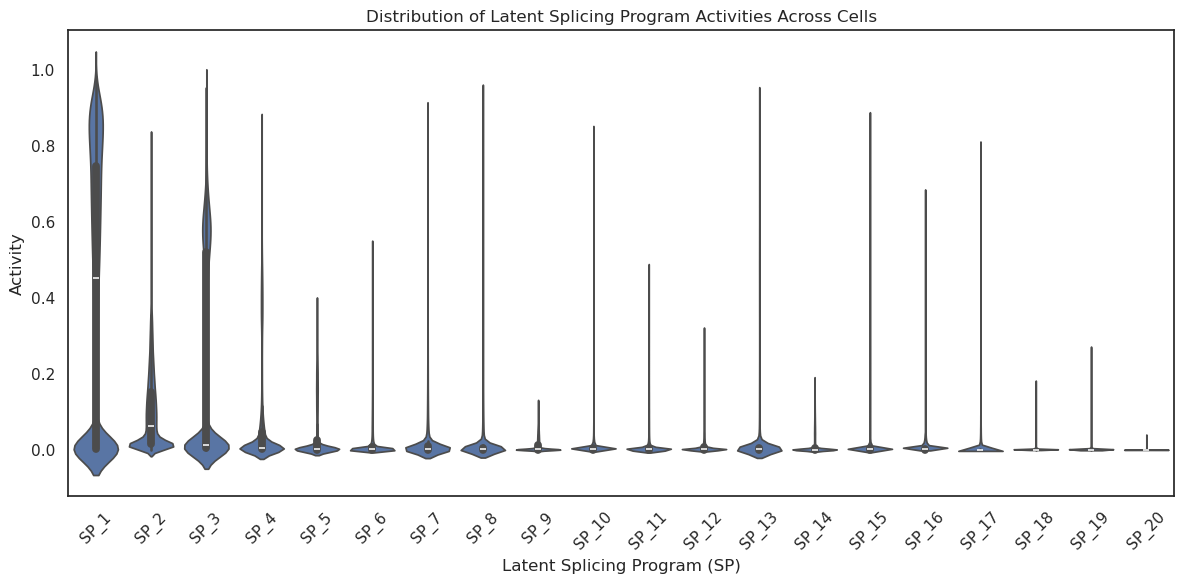

In [62]:
# Extract X_PHI matrix and convert to DataFrame
phi = pd.DataFrame(
    splice_adata.obsm["X_PHI"],
    index=splice_adata.obs["cell_id"]
)
phi.columns = [f"SP_{i+1}" for i in range(phi.shape[1])]

phi_long = phi.reset_index().melt(id_vars="cell_id", var_name="Splicing Program", value_name="Activity")

# Plot
plt.figure(figsize=(12, 6))  # Adjust width as needed
sns.violinplot(data=phi_long, x="Splicing Program", y="Activity", inner="box", scale="width")
plt.xticks(rotation=45)
plt.title("Distribution of Latent Splicing Program Activities Across Cells")
plt.xlabel("Latent Splicing Program (SP)")
plt.ylabel("Activity")
plt.tight_layout()
plt.show()

In [63]:
# Clean up Broad Cell Type column
splice_adata.obs["broad_cell_type"] = splice_adata.obs["broad_cell_type"].str.title()
splice_adata.obs["age_numeric"] = splice_adata.obs["age_numeric"]
splice_adata.obs["broad_cell_type"] = splice_adata.obs["broad_cell_type"]

In [64]:
# Setup
phi_matrix = splice_adata.obsm["X_PHI"]
factor_names = [f"SP_{i+1}" for i in range(phi_matrix.shape[1])]

# Build DataFrame
phi_df = pd.DataFrame(phi_matrix, index=splice_adata.obs_names, columns=factor_names)
phi_df["broad_cell_type"] = splice_adata.obs["broad_cell_type"].values
phi_df["age_group"] = splice_adata.obs["age_group"].values

# Output dirs
output_dir_celltype = "./factor_violin_plots_by_celltype"
output_dir_agegroup = "./factor_violin_plots_by_agegroup"
output_dir_factors_by_celltype = "./factor_violin_per_celltype"

os.makedirs(output_dir_factors_by_celltype, exist_ok=True)
os.makedirs(output_dir_celltype, exist_ok=True)
os.makedirs(output_dir_agegroup, exist_ok=True)

In [65]:
# Toggle this to enable or disable plotting
MAKE_PLOTS = False

if MAKE_PLOTS:
    # --- Plot factor activity across broad cell types ---
    for factor in factor_names:
        # Order broad_cell_type by decreasing median activity
        medians = phi_df.groupby("broad_cell_type")[factor].median().sort_values(ascending=False)
        ordered_types = medians.index.tolist()

        plt.figure(figsize=(10, 5))
        sns.violinplot(
            data=phi_df, x="broad_cell_type", y=factor,
            order=ordered_types, inner="box", scale="width",
            fill="simple_category"
        )
        plt.xticks(rotation=45, ha='right')
        plt.title(f"{factor} Activity Across Broad Cell Types")
        plt.xlabel("Broad Cell Type")
        plt.ylabel("Factor Activity")
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir_celltype, f"{factor}_by_celltype_violin.pdf"))
        plt.close()

    # --- Plot factor activity across age groups ---
    for factor in factor_names:
        # Define age group order (assumes string labels like "3m", "18m", etc.)
        age_order = phi_df["age_group"].unique().tolist()
        age_order.sort()

        plt.figure(figsize=(6, 5))
        sns.violinplot(
            data=phi_df, x="age_group", y=factor,
            order=age_order, inner="box", scale="width"
        )
        plt.title(f"{factor} Activity Across Age Groups")
        plt.xlabel("Age Group")
        plt.ylabel("Factor Activity")
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir_agegroup, f"{factor}_by_agegroup_violin.pdf"))
        plt.close()

    # --- Melt wide-format dataframe into long-form for factor plotting ---
    phi_long = phi_df.reset_index().melt(
        id_vars=["cell_id", "broad_cell_type", "age_group"],
        value_vars=factor_names,
        var_name="Factor", value_name="Activity"
    )

    # --- Plot violin plots of all factors within each cell type ---
    for celltype in phi_df["broad_cell_type"].unique():
        # Subset data to current cell type
        subset = phi_long[phi_long["broad_cell_type"] == celltype]

        # Order factors by median activity within the current cell type
        median_order = (
            subset.groupby("Factor")["Activity"]
            .median()
            .sort_values(ascending=False)
            .index.tolist()
        )

        plt.figure(figsize=(14, 5))
        sns.violinplot(
            data=subset, x="Factor", y="Activity",
            order=median_order, inner="box", scale="width"
        )
        plt.xticks(rotation=45, ha='right')
        plt.title(f"Factor Activity in {celltype} (Ordered by Median)")
        plt.xlabel("Factor")
        plt.ylabel("Activity")
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir_factors_by_celltype, f"{celltype}_factor_activity_violin.pdf"))
        plt.close()

## Visualize Pi vs PVE

In [66]:
# get reordered pi values 
new_pi = pi[new_order]

# visualize global learned pi values, vs how much variance each one explains across cells PHI? 
# How much variance each factor contributes in the loadings
phi_var = np.var(splice_adata.obsm["X_PHI"], axis=0)  # Variance across cells for each factor
pve_factor_space = phi_var / np.sum(phi_var)
print(pve_factor_space)

[4.62372695e-01 3.33069429e-02 2.63909397e-01 5.93519039e-02
 2.02442258e-02 4.54443915e-03 4.90022523e-02 4.25365570e-02
 1.29878640e-03 2.31055705e-03 5.02184057e-03 2.06518202e-03
 4.66411920e-02 2.33355028e-03 4.10285275e-03 1.75092130e-04
 6.82580185e-04 7.39708063e-06 9.05349932e-05 2.02096051e-06]


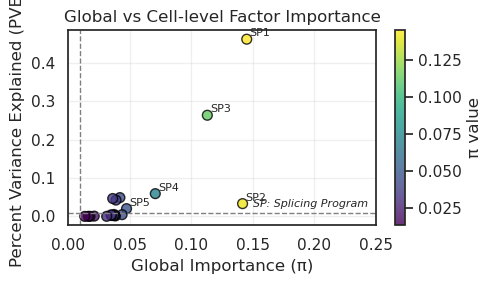

In [67]:
# Simple scatter plot
plt.figure(figsize=(5, 3))

# Use scatter with edgecolors for black outline and c parameter for color mapping
plt.scatter(new_pi, pve_factor_space, s=50, alpha=0.8, 
            c=new_pi, cmap='viridis', edgecolors='black', linewidth=1)

# Add colorbar to show π value mapping
plt.colorbar(label='π value')

# Add factor labels for interesting points
for i in range(len(new_pi)):
    if i < 5 or pve_factor_space[i] > 0.05:  # Label first 3 and high variance factors
        plt.annotate(f'SP{i+1}', (new_pi[i], pve_factor_space[i]), 
                    xytext=(2, 2), textcoords='offset points', fontsize=8)  # Increased from (5,5) to (10,10)

plt.xlabel('Global Importance (π)')
plt.ylabel('Percent Variance Explained (PVE)')
plt.title('Global vs Cell-level Factor Importance')
plt.xlim(0, 0.25)

# add dashed hori line at 0.01
plt.axhline(0.01, color='gray', linestyle='--', linewidth=1)
plt.axvline(0.01, color='gray', linestyle='--', linewidth=1)

# Add SP definition at bottom of plot
plt.text(0.15, 0.02, 'SP: Splicing Program', fontsize=8, style='italic', 
         transform=plt.gca().transData, verticalalignment='bottom')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Plot saved to: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/factor_pi_vs_pve.pdf


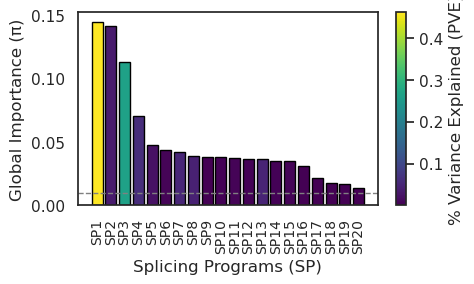

In [68]:
# Assume new_pi and pve_factor_space already exist
num_factors = len(new_pi)
factor_labels = [f'SP{i+1}' for i in range(num_factors)]

# Normalize PVE for colormap
norm = plt.Normalize(pve_factor_space.min(), pve_factor_space.max())
colors = plt.cm.viridis(norm(pve_factor_space))

# Set up figure and axis
fig, ax = plt.subplots(figsize=(5, 3))

# Bar plot
bars = ax.bar(
    factor_labels,
    new_pi,
    color=colors,
    edgecolor='black'
)

# Create scalar mappable and colorbar
sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array([])  # Required dummy
cbar = plt.colorbar(sm, ax=ax)  # Pass ax explicitly
cbar.set_label("% Variance Explained (PVE)")

# Add horizontal threshold line
ax.axhline(0.01, color='gray', linestyle='--', linewidth=1)

# Formatting
ax.set_ylabel('Global Importance (π)')
ax.set_xlabel('Splicing Programs (SP)')
# ax.set_title('Factor Importance (π), colored by PVE')
ax.set_xticks(np.arange(num_factors))
ax.set_xticklabels(factor_labels, rotation=90, fontsize=10)

plt.tight_layout()

# Save to output_dir with today's date OUTPUT_DIR 
output_path = os.path.join(OUTPUT_DIR, f"factor_pi_vs_pve.pdf")
plt.savefig(output_path, format='pdf', bbox_inches='tight')
print(f"Plot saved to: {output_path}")

plt.show()


## Visualize Perplexity

In [69]:
# Step 2: Reindex to match AnnData.obs_names (i.e., cell IDs)
perplexity_df = perplexity_df.reindex(splice_adata.obs_names)

# Step 3: Add as a new column in AnnData.obs
splice_adata.obs["perplexity"] = perplexity_df["perplexity"].values

# Step 4: Filter medium_cell_types with >= 50 cells
valid_medium_ct = (
    splice_adata.obs["medium_cell_type"]
    .value_counts()[lambda x: x >= 50]
    .index
)

# Subset AnnData object to only those cells
splice_adata = splice_adata[splice_adata.obs["medium_cell_type"].isin(valid_medium_ct)].copy()

# Ensure ge_adata is subsetted to match
ge_adata = ge_adata[ge_adata.obs["medium_cell_type"].isin(valid_medium_ct)].copy()

# Assert order of cells is the same
assert np.all(ge_adata.obs_names == splice_adata.obs_names)

In [70]:
splice_adata, ge_adata

(AnnData object with n_obs × n_vars = 137893 × 35197
     obs: 'cell_id_index', 'age', 'cell_ontology_class', 'donor_id', 'sex', 'subtissue', 'tissue', 'dataset', 'cell_name', 'cell_id', 'cell_clean', 'specific_cell_type', 'broad_cell_type', 'medium_cell_type', 'seqtech', 'library_size', 'total_junction_reads', 'annotated_junction_reads', 'unannotated_junction_reads', 'n_detected_annotated_junctions', 'n_detected_unannotated_junctions', 'AgingScore_unweighted', 'AgingScore_pos', 'AgingScore_neg', 'nuclear_ratio_log_norm', 'age_numeric', 'age_group', 'perplexity', 'total_counts', 'nuclear_class_log_norm', 'nuclear_score_log_norm', 'SP_1', 'SP_2', 'SP_3', 'SP_4', 'SP_5', 'SP_6', 'SP_7', 'SP_8', 'SP_9', 'SP_10', 'SP_11', 'SP_12', 'SP_13', 'SP_14', 'SP_15', 'SP_16', 'SP_17', 'SP_18', 'SP_19', 'SP_20'
     var: 'junction_id', 'event_id', 'splice_motif', 'annotation_status', 'gene_name', 'gene_id', 'num_junctions', 'position_off_5_prime', 'position_off_3_prime', 'CountJuncs', 'n_cells_detect

Saved plot to: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/perplexity_by_age_rasterized.pdf


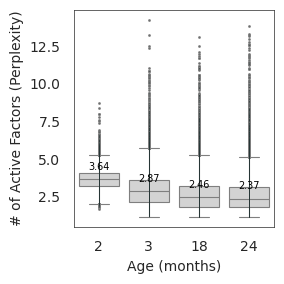

In [71]:
plt.figure(figsize=(3, 3))

# Boxplot: keep as vector
sns.boxplot(
    data=splice_adata.obs,
    x="age_numeric", 
    y="perplexity", 
    color="lightgray", 
    fliersize=1, 
    linewidth=0.8
)

# Stripplot: will rasterize below
stripplot = sns.stripplot(
    data=splice_adata.obs,
    x="age_numeric", 
    y="perplexity", 
    color="darkslategrey", 
    size=0.5, 
    jitter=False,
    alpha=0.3
)

# 🟡 Rasterize only the point cloud layer
for c in stripplot.collections:
    c.set_rasterized(True)

# Median labels
medians = (
    splice_adata.obs
    .groupby("age_numeric", observed=True)["perplexity"]
    .median()
)
for i, (age, median_val) in enumerate(medians.items()):
    plt.text(
        x=i,
        y=median_val + 0.5,
        s=f"{median_val:.2f}",
        ha='center',
        va='bottom',
        fontsize=7,
        color='black'
    )

# Formatting
plt.xlabel("Age (months)", fontsize=10)
plt.ylabel("# of Active Factors (Perplexity)", fontsize=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

for spine in plt.gca().spines.values():
    spine.set_linewidth(0.5)

plt.tight_layout()

# Save to PDF with rasterized points
output_path = f"{OUTPUT_DIR}/perplexity_by_age_rasterized.pdf"
plt.savefig(output_path, bbox_inches='tight', dpi=300)
print(f"Saved plot to: {output_path}")
plt.show()

In [72]:
splice_adata.obs["medium_cell_type"].value_counts()

medium_cell_type
Cortical excitatory neuron      28335
Inhibitory neuron               15936
Microglia                       12079
B cell                           8640
Skin epithelial cell             7343
Endothelial cell                 7103
Mesenchymal stem cell            4780
Fibroblast                       4623
Hippocampal neuron               3993
T cell                           3588
T cell precursor                 3012
Intestinal epithelial cell       2940
Granulocyte                      2864
Hematopoietic stem cell          2749
Other immune cell                2575
Skeletal muscle cell             2469
Macrophage                       2154
Smooth muscle cell               2056
Pancreatic endocrine cell        1454
Oligodendrocyte                  1334
Monocyte                         1295
Specialized intestinal cell      1290
Immune progenitor                1210
Basal epithelial cell            1149
Urogenital epithelial cell       1014
Epithelial stem cell             

Saved rasterized plot to: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/perplexity_by_cell_type_ordered_rasterized.pdf


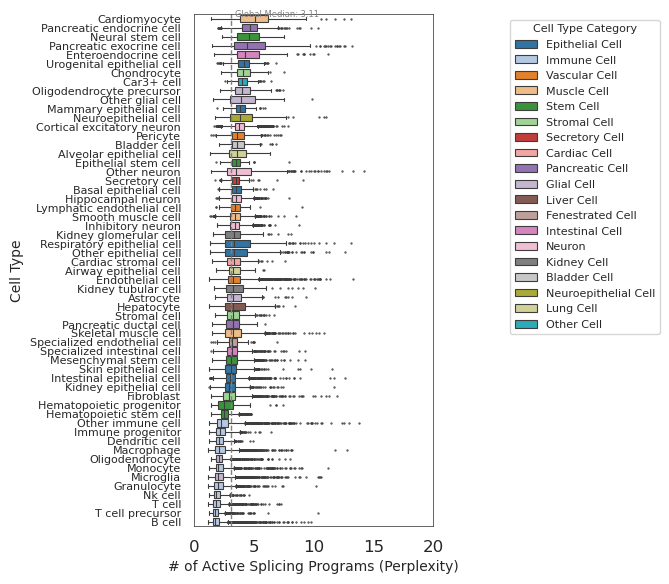

In [73]:
# Step 1: Compute median perplexity by medium_cell_type
median_order = (
    splice_adata.obs
    .groupby("medium_cell_type", observed=True)["perplexity"]
    .median()
    .sort_values(ascending=False)
    .index
)

# Step 2: Color palette for broad_cell_type
unique_broad = splice_adata.obs["broad_cell_type"].unique()
palette = sns.color_palette("tab20", len(unique_broad))
palette_dict = dict(zip(unique_broad, palette))

# Step 3: Start figure
fig, ax = plt.subplots(figsize=(8, 6))

# Step 4: Main plot
bp = sns.boxplot(
    data=splice_adata.obs,
    y="medium_cell_type", 
    x="perplexity", 
    hue="broad_cell_type", 
    fliersize=0.6, 
    linewidth=0.8,
    order=median_order,
    palette=palette_dict,
    ax=ax
)

# Rasterize fliers
for c in ax.collections:
    if isinstance(c, plt.collections.PathCollection):
        c.set_rasterized(True)

# Global median line
global_median = splice_adata.obs["perplexity"].median()
ax.axvline(global_median, color='gray', linestyle='--', linewidth=1)
ax.text(global_median + 0.3, -1, f"Global Median: {global_median:.2f}",
        color='gray', fontsize=6, va='top')

# Legend
ax.legend(
    title="Cell Type Category",
    bbox_to_anchor=(1.3, 1),
    loc='upper left',
    fontsize=8,
    title_fontsize=8,
    frameon=True
)

# Axis formatting
ax.set_ylabel("Cell Type", fontsize=10)
ax.set_xlabel("# of Active Splicing Programs (Perplexity)", fontsize=10)
ax.set_xticks(np.arange(0, 25, 5))
ax.set_xticklabels(np.arange(0, 25, 5), fontsize=12)
ax.tick_params(axis='y', labelsize=8)  # ⬅️ Smaller font for cell type labels

# Border
for spine in ax.spines.values():
    spine.set_linewidth(0.5)

# Save
plt.tight_layout()
pdf_path = f"{OUTPUT_DIR}/perplexity_by_cell_type_ordered_rasterized.pdf"
plt.savefig(pdf_path, bbox_inches='tight', dpi=300)
print(f"Saved rasterized plot to: {pdf_path}")
plt.show()

### Figure 2 Factor Covaraites Labels

In [74]:
# Remake PHI matrix correlation plot
X_PHI_corr_matrix = plot_correlation_matrix(splice_adata.obsm["X_PHI"], OUTPUT_DIR)

In [75]:
import sys
sys.path.append("/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils")

import utils  # or: from utils import your_function
import importlib
importlib.reload(utils)

<module 'utils' from '/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils/utils.py'>

In [76]:
# read in factor labels 
factor_labels_broad_cell_type = utils.run_variance_explained_analysis(splice_adata, cell_type_col="broad_cell_type", sample_id="dataset", PLOTS_DIR=OUTPUT_DIR)

Running variance explained analysis...
broad_cell_type
Neuron                  48864
Immune Cell             26428
Epithelial Cell         14535
Glial Cell              14234
Stem Cell                8662
Vascular Cell            7541
Stromal Cell             5421
Muscle Cell              4963
Pancreatic Cell          2135
Intestinal Cell          1399
Other Cell                789
Liver Cell                714
Cardiac Cell              576
Bladder Cell              526
Secretory Cell            281
Lung Cell                 251
Fenestrated Cell          240
Kidney Cell               217
Neuroepithelial Cell      117
Name: count, dtype: int64
tissue
Brain_Non-Myeloid    54060
Brain_Myeloid        12368
Marrow               11785
Heart                 7904
Large_Intestine       5452
Lung                  4568
Skin                  4307
Thymus                3545
Limb_Muscle           3436
Spleen                3171
Tongue                3093
GAT                   2959
SCAT              

Analyzing factors for variance explained:   0%|          | 0/20 [00:00<?, ?it/s]

  Formula: Factor_1 ~ C(cell_type) + C(tissue) + C(sex) + C(dataset) + age + C(cell_type):age + C(tissue):age + C(sex):age


Analyzing factors for variance explained:   5%|▌         | 1/20 [00:02<00:53,  2.82s/it]

  Formula: Factor_2 ~ C(cell_type) + C(tissue) + C(sex) + C(dataset) + age + C(cell_type):age + C(tissue):age + C(sex):age


...

  Formula: Factor_19 ~ C(cell_type) + C(tissue) + C(sex) + C(dataset) + age + C(cell_type):age + C(tissue):age + C(sex):age


Analyzing factors for variance explained:  95%|█████████▌| 19/20 [00:52<00:02,  2.64s/it]

  Formula: Factor_20 ~ C(cell_type) + C(tissue) + C(sex) + C(dataset) + age + C(cell_type):age + C(tissue):age + C(sex):age


Analyzing factors for variance explained: 100%|██████████| 20/20 [00:54<00:00,  2.73s/it]


  Saved variance explained heatmap to /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/variance_explained_heatmap_broad_cell_type.pdf


In [77]:
# read in factor labels 
factor_labels_medium_cell_type = utils.run_variance_explained_analysis(splice_adata, cell_type_col="medium_cell_type", sample_id="dataset", PLOTS_DIR=OUTPUT_DIR)

Running variance explained analysis...
medium_cell_type
Cortical excitatory neuron      28335
Inhibitory neuron               15936
Microglia                       12079
B cell                           8640
Skin epithelial cell             7343
Endothelial cell                 7103
Mesenchymal stem cell            4780
Fibroblast                       4623
Hippocampal neuron               3993
T cell                           3588
T cell precursor                 3012
Intestinal epithelial cell       2940
Granulocyte                      2864
Hematopoietic stem cell          2749
Other immune cell                2575
Skeletal muscle cell             2469
Macrophage                       2154
Smooth muscle cell               2056
Pancreatic endocrine cell        1454
Oligodendrocyte                  1334
Monocyte                         1295
Specialized intestinal cell      1290
Immune progenitor                1210
Basal epithelial cell            1149
Urogenital epithelial cell      

Analyzing factors for variance explained:   0%|          | 0/20 [00:00<?, ?it/s]

  Formula: Factor_1 ~ C(cell_type) + C(tissue) + C(sex) + C(dataset) + age + C(cell_type):age + C(tissue):age + C(sex):age


Analyzing factors for variance explained:   5%|▌         | 1/20 [00:04<01:21,  4.29s/it]

  Formula: Factor_2 ~ C(cell_type) + C(tissue) + C(sex) + C(dataset) + age + C(cell_type):age + C(tissue):age + C(sex):age


...

  Formula: Factor_19 ~ C(cell_type) + C(tissue) + C(sex) + C(dataset) + age + C(cell_type):age + C(tissue):age + C(sex):age


Analyzing factors for variance explained:  95%|█████████▌| 19/20 [01:23<00:04,  4.40s/it]

  Formula: Factor_20 ~ C(cell_type) + C(tissue) + C(sex) + C(dataset) + age + C(cell_type):age + C(tissue):age + C(sex):age


Analyzing factors for variance explained: 100%|██████████| 20/20 [01:27<00:00,  4.39s/it]


  Saved variance explained heatmap to /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/variance_explained_heatmap_medium_cell_type.pdf


In [78]:
import sys
sys.path.append("/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils")
import figure_plotting
import importlib
importlib.reload(figure_plotting)

<module 'figure_plotting' from '/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils/figure_plotting.py'>

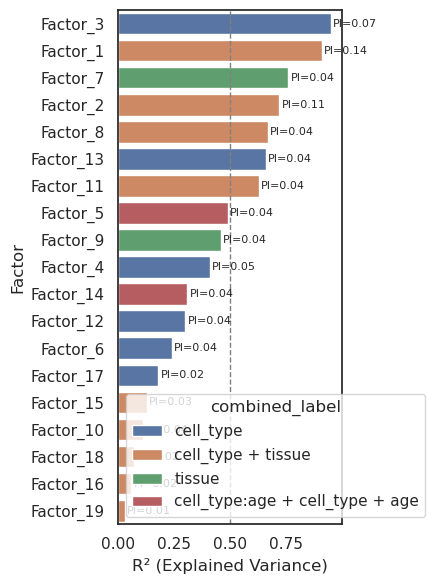

In [79]:
factor_labels_broad_cell_type['combined_label'] = factor_labels_broad_cell_type.apply(relabel_covariate, axis=1)
# Save a new ordered version of pi
new_pi = pi[new_order]
fig, ax = figure_plotting.plot_covariates_factor_labels(new_pi, factor_labels_broad_cell_type, save_path=f"{OUTPUT_DIR}/combined_labels_anova_broad_cell_type.pdf")

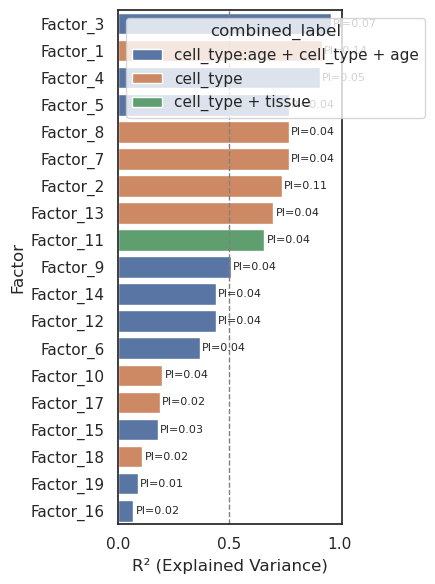

In [80]:
factor_labels_medium_cell_type['combined_label'] = factor_labels_medium_cell_type.apply(relabel_covariate, axis=1)
# Save a new ordered version of pi
new_pi = pi[new_order]
fig, ax = figure_plotting.plot_covariates_factor_labels(new_pi, factor_labels_medium_cell_type, save_path=f"{OUTPUT_DIR}/combined_labels_anova_medium_cell_type.pdf")

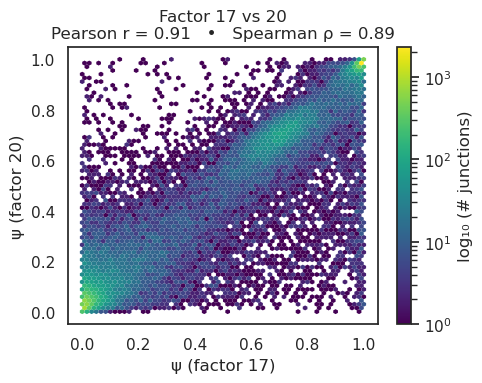

In [81]:
# examples ───────────────────────────────────────────────────────────────────
plot_factor_corr(splice_adata, f_x=17,  f_y=20)       # factors 2 vs 15, 1-based


Top 2 positively correlated factor pairs:
factor_i factor_j      rho
     SP8     SP13 0.566261
     SP1      SP7 0.563102

Top 2 negatively correlated factor pairs:
factor_i factor_j       rho
    SP14     SP15 -0.311977
    SP14     SP17 -0.291739

Top 2 least correlated factor pairs:
factor_i factor_j       rho
     SP9     SP12 -0.003205
    SP16     SP18  0.004100


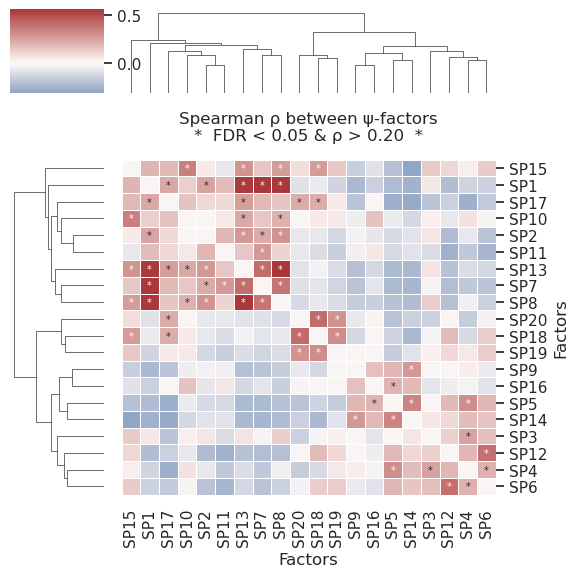

In [82]:
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests   # pip install statsmodels

# ── 1.  Data → DataFrame ───────────────────────────────────────────────────────
ψ  = splice_adata.varm["psi_learned"]          # (J, K)
K  = ψ.shape[1]

# Subtract row (junction) mean from each factor value
ψ_centered = ψ - np.nanmean(ψ, axis=1, keepdims=True)
K = ψ_centered.shape[1]
df = pd.DataFrame(ψ_centered, columns=[f"SP{j+1}" for j in range(K)])

# ── 2.  ρ and p-values for *each* pair ─────────────────────────────────────────
rho    = np.zeros((K, K))
pvals  = np.ones((K, K))

for i in range(K):
    for j in range(i+1, K):
        r, p = spearmanr(df.iloc[:, i], df.iloc[:, j], nan_policy='omit')
        rho[i, j] = rho[j, i] = r
        pvals[i, j] = pvals[j, i] = p

# ── 3.  Benjamini–Hochberg FDR adjustment over the upper triangle ─────────────
tri_idx         = np.triu_indices(K, k=1)          # exclude the diagonal
p_flat          = pvals[tri_idx]
_, q_flat, _, _ = multipletests(p_flat, method="fdr_bh")
qvals           = np.ones_like(pvals)
qvals[tri_idx]  = qvals.T[tri_idx] = q_flat

# ── 4.  Significance mask  (FDR < 0.05 and ρ > 0.20) ──────────────────────────
star_mask = (qvals < 0.05) & (rho > 0.20)
annot     = np.where(star_mask, "*", "")

# ── 5.  Build DataFrames with indices/columns for seaborn ─────────────────────
rho_df   = pd.DataFrame(rho,   index=df.columns, columns=df.columns)
annot_df = pd.DataFrame(annot, index=df.columns, columns=df.columns)


# ── 1.  clustered heat-map with all tick labels ───────────────────────────────
sns.set_theme(style="white")
g = sns.clustermap(
    rho_df,
    cmap="vlag", center=0, linewidths=0.4, square=True,
    metric="euclidean", row_cluster=True, col_cluster=True,
    figsize=(6, 6),
    annot=annot_df, fmt="", annot_kws={"size":7},
    xticklabels=True, yticklabels=True
)

# Rotate x-labels so they don’t overlap
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=90)
plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0)

g.ax_heatmap.set_title("Spearman ρ between ψ-factors\n*  FDR < 0.05 & ρ > 0.20  *", pad=14)
g.ax_heatmap.set_xlabel("Factors")
g.ax_heatmap.set_ylabel("Factors")

plt.tight_layout()

# ── 2.  save to disk ──────────────────────────────────────────────────────────
g.savefig(f"{OUTPUT_DIR}/psi_factor_spearman_clustermap.pdf", bbox_inches="tight")

# ── 3.  report extreme pairs ──────────────────────────────────────────────────
# flatten upper triangle (exclude diagonal), keep finite values only
tri_i, tri_j = np.triu_indices_from(rho_df, k=1)
tri_vals = rho_df.values[tri_i, tri_j]

# build a DataFrame for easy sorting
pairs_df = pd.DataFrame({
    "factor_i": rho_df.index[tri_i],
    "factor_j": rho_df.columns[tri_j],
    "rho":      tri_vals
}).dropna()

# top 2 positive
top_pos = pairs_df.nlargest(2, "rho")
# top 2 negative
top_neg = pairs_df.nsmallest(2, "rho")
# top 2 least correlated (closest to zero)
top_flat = pairs_df.iloc[(pairs_df["rho"].abs()).nsmallest(2).index]

print("\nTop 2 positively correlated factor pairs:")
print(top_pos.to_string(index=False))

print("\nTop 2 negatively correlated factor pairs:")
print(top_neg.to_string(index=False))

print("\nTop 2 least correlated factor pairs:")
print(top_flat.to_string(index=False))


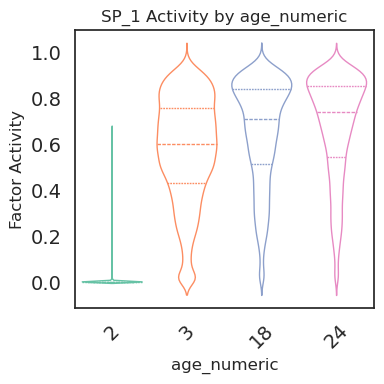

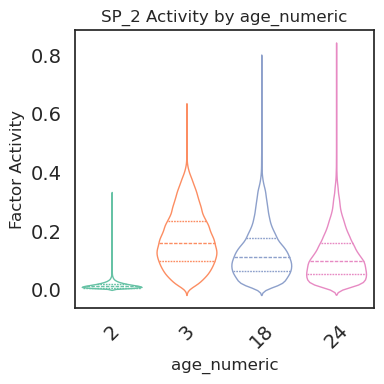

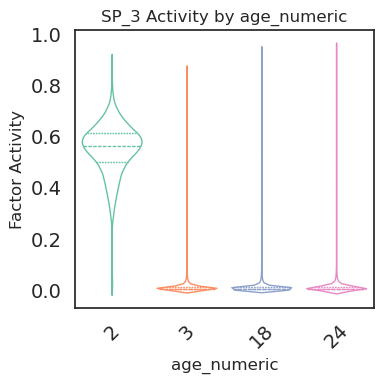

In [83]:
plot_factor_violin(
    adata=splice_adata,
    factor_list=["SP_1", "SP_2", "SP_3"],
    groupby="age_numeric",
    save_prefix="factor_age_violin"
)

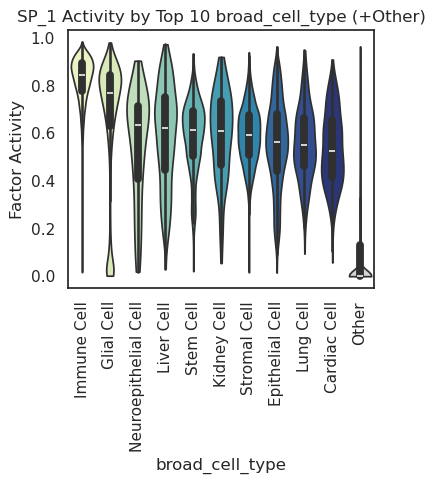

In [84]:
plot_factor_violin_sorted(
    adata=splice_adata,
    factor_list=["SP_1"],
    groupby="broad_cell_type",
    top_n=10,
    cmap="YlGnBu",
    save_prefix="sorted_violin",
    width=4,
    height=5
)

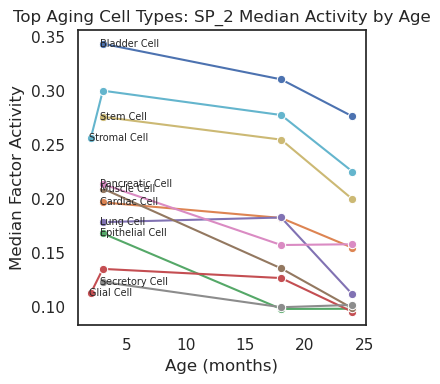

In [85]:
plot_factor_age_trends(
    df=splice_adata.obs,
    factor="SP_2",
    top_n=10,
    title_prefix="Top Aging Cell Types",
    save_path=f"{OUTPUT_DIR}/Factor_2_age_trend_top5.pdf"
)


### Get heatmap for common cell types 

Saved plot to /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/clustering_common_celltype_dataset_factors.pdf


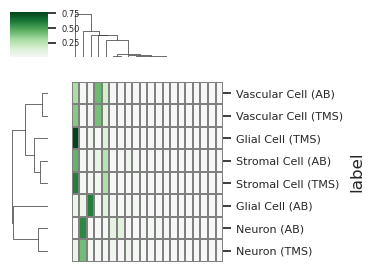

In [86]:
# Get cell type counts by dataset to get common cell types
# Get cell type counts by dataset to get common cell types
cell_type_counts = splice_adata.obs.groupby(['broad_cell_type', 'dataset']).size().unstack()
common_cell_types = cell_type_counts[(cell_type_counts["AB"] > 0) & (cell_type_counts["TMS"] > 0)]
common_cell_type_names = common_cell_types.index.tolist()

# Subset to common cell types
adata_common = splice_adata[
    splice_adata.obs["broad_cell_type"].isin(common_cell_type_names)
].copy()

# Convert to categorical first
adata_common.obs["broad_cell_type"] = adata_common.obs["broad_cell_type"].astype("category")
adata_common.obs["broad_cell_type"] = adata_common.obs["broad_cell_type"].cat.remove_unused_categories()

# Extract factor matrix and build DataFrame
num_factors = adata_common.obsm["X_PHI"].shape[1]
factor_cols = [f"Factor_{i+1}" for i in range(num_factors)]

df = adata_common.obs[["broad_cell_type", "dataset"]].copy()
for i, col in enumerate(factor_cols):
    df[col] = adata_common.obsm["X_PHI"][:, i]

# Compute median factor values by cell type and dataset
median_profiles = (
    df.groupby(["broad_cell_type", "dataset"], observed=True)[factor_cols]
    .median()
    .reset_index()
)

# Create composite labels
median_profiles["label"] = (
    median_profiles["broad_cell_type"].astype(str)
    + " (" +
    median_profiles["dataset"].astype(str)
    + ")"
)

# Set label as index
median_profiles = median_profiles.set_index("label")[factor_cols]

# Plot clustermap
g = sns.clustermap(
    median_profiles,
    method="average",
    metric="euclidean",
    cmap="PRGn",
    center=0,
    linewidths=0.2,
    linecolor='gray',
    figsize=(4, 3)
)

# Remove x-axis tick labels (factors)
g.ax_heatmap.set_xticks([])
g.ax_heatmap.set_xticklabels([])

# Format y-axis (cell types)
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), fontsize=8)

# Colorbar label and tick font
g.ax_cbar.set_label("Median Factor Activity")
g.ax_cbar.yaxis.label.set_size(7)
g.ax_cbar.tick_params(labelsize=6)

# Save
plt.tight_layout()
g.savefig(f"{OUTPUT_DIR}/clustering_common_celltype_dataset_factors.pdf", bbox_inches='tight')
print(f"Saved plot to {OUTPUT_DIR}/clustering_common_celltype_dataset_factors.pdf")
plt.show()

In [87]:
splice_adata.obs["broad_cell_type"] = splice_adata.obs["broad_cell_type"].astype("category")
splice_adata.obs["medium_cell_type"] = splice_adata.obs["medium_cell_type"].astype("category")

  broad_cell_type age_numeric      SP_1
0    Bladder Cell           3  0.446596
1    Bladder Cell          18  0.516388
2    Bladder Cell          24  0.585680


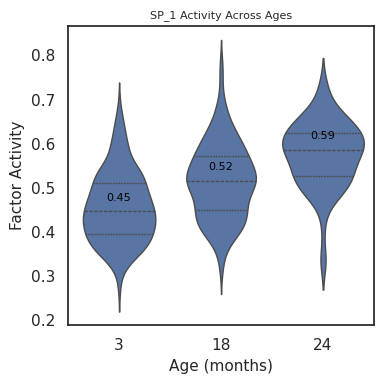

In [88]:
plot_factor_violin_by_age(
    df=splice_adata.obs,
    factor="SP_1",
    cell_types=["Bladder Cell"],
    figsize=(4, 4), save_path=f"{OUTPUT_DIR}/F10_SecretoryCells.pdf"
)


In [89]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Extract age and perplexity
X = splice_adata.obs[["age_numeric"]].values  # shape (n_cells, 1)
y = splice_adata.obs["perplexity"].values  # shape (n_cells,)

# Fit linear regression
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

# Compute R²
r2 = r2_score(y, y_pred)
print(f"R² (perplexity ~ age): {r2:.4f}")

R² (perplexity ~ age): 0.1221


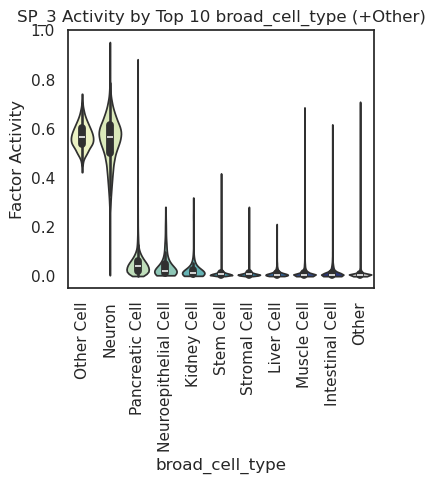

In [90]:
plot_factor_violin_sorted(
    adata=splice_adata,
    factor_list=["SP_3"],
    groupby="broad_cell_type",
    top_n=10,
    cmap="YlGnBu",
    save_prefix="sorted_violin",
    width=4,
    height=5
)

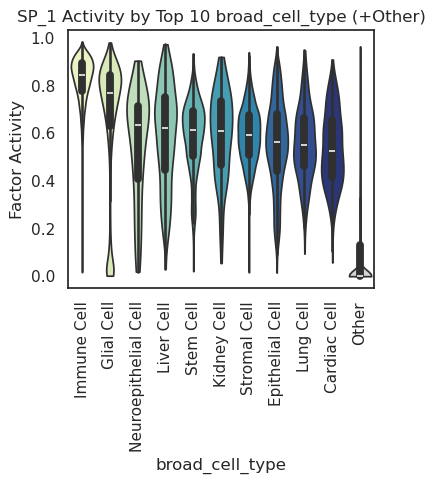

In [91]:
plot_factor_violin_sorted(
    adata=splice_adata,
    factor_list=["SP_1"],
    groupby="broad_cell_type",
    top_n=10,
    cmap="YlGnBu",
    save_prefix="sorted_violin",
    width=4,
    height=5
)

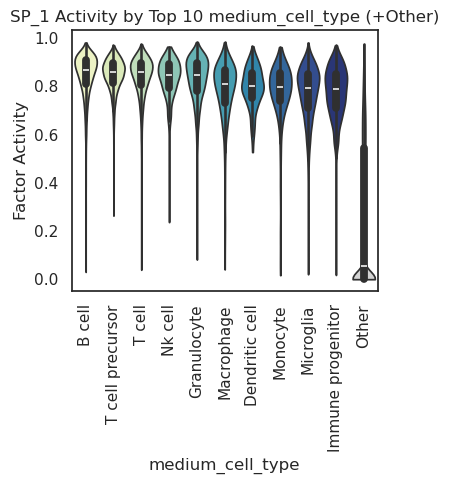

In [92]:
plot_factor_violin_sorted(
    adata=splice_adata,
    factor_list=["SP_1"],
    groupby="medium_cell_type",
    top_n=10,
    cmap="YlGnBu",
    save_prefix="sorted_violin",
    width=4,
    height=5
)


## Look at sig junctions from differential splicing analysis

In [93]:
# Run the analysis
print("="*60)
print("TOP JUNCTIONS PER FACTOR PSI ANALYSIS")
print("="*60)

# Step 1: Get top junctions per factor
top_junctions_dict, subset_splice_adata, junction_factor_map = get_top_junctions_per_factor(
    diff_spl, 
    splice_adata, 
    top_n=10, 
    effect_size_col='abs_effect_size'
)

# Get unique junction indices
unique_junctions = junction_factor_map['junction_idx'].unique()

# Extract PSI learned values for these junctions
psi_subset = splice_adata.varm['psi_learned'][unique_junctions, :]

TOP JUNCTIONS PER FACTOR PSI ANALYSIS
Getting top 10 junctions per factor...
Ranking by: abs_effect_size
Found 20 factors: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
Factor 0: 10 junctions, effect size range: 0.961 - 0.991
Factor 1: 10 junctions, effect size range: 0.851 - 0.916
Factor 2: 10 junctions, effect size range: 0.782 - 0.905
Factor 3: 10 junctions, effect size range: 0.907 - 0.959
Factor 4: 10 junctions, effect size range: 0.920 - 0.966
Factor 5: 10 junctions, effect size range: 0.894 - 0.953
Factor 6: 10 junctions, effect size range: 0.979 - 0.997
Factor 7: 10 junctions, effect size range: 0.971 - 0.990
Factor 8: 10 junctions, effect size range: 0.915 - 0.974
Factor 9: 10 junctions, effect size range: 0.798 - 0.913
Factor 10: 10 junctions, effect size range: 0.943 - 0.985
Factor 11: 10 junctions, effect size range: 0.910 - 0.969
Factor 12: 10 junctions, effect size range: 0.937 - 0.989
Factor 13: 10 junctions, effect size range: 0.891 - 0.921
Fact

Saved plot to /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-30/2025-07-31/param_id_0/analysis_outputs/psi_clustermap_top_10.pdf


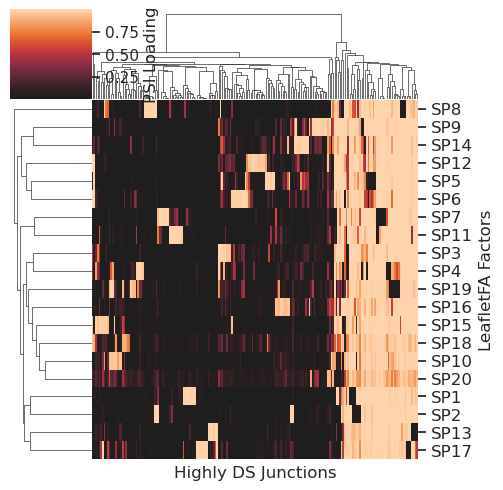

In [94]:
# 1. Map row labels: get junction_id or gene_name from .var
# Get the integer indices into .varm (which uses original order)
unique_junctions = junction_factor_map['junction_idx'].unique()
# psi_learned: shape (n_junctions, n_factors), so index using integer indices
psi_subset = splice_adata.varm['psi_learned'][unique_junctions, :]
junction_id = splice_adata.var[splice_adata.var["junction_id_index"].isin(unique_junctions)]["junction_id"].values
gene_name = splice_adata.var[splice_adata.var["junction_id_index"].isin(unique_junctions)]["gene_name"].values

# Get number of factors (rows after transpose)
num_factors = psi_subset.shape[1]

# Create factor labels: F1, F2, ..., FK
factor_labels = [f"SP{i+1}" for i in range(num_factors)]

# 2. Create clustermap with color tweaks
g = sns.clustermap(
    psi_subset.T,
    center=0,
    figsize=(6, 5),
    xticklabels=False,
    yticklabels=factor_labels,
    cbar_kws={'label': 'PSI Loading'},
    robust=True  # clip extreme values for better contrast
)

# 3. Style adjustments
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=90, fontsize=8)
plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=12)
g.ax_heatmap.set_ylabel("LeafletFA Factors")
g.ax_heatmap.set_xlabel("Highly DS Junctions")
plt.subplots_adjust(left=0.3, bottom=0.05, top=0.95, right=0.98)
save_path = os.path.join(OUTPUT_DIR, "psi_clustermap_top_10.pdf")
g.savefig(save_path, bbox_inches="tight")
print(f"Saved plot to {save_path}")
plt.show()

In [95]:
splice_adata

AnnData object with n_obs × n_vars = 137893 × 35197
    obs: 'cell_id_index', 'age', 'cell_ontology_class', 'donor_id', 'sex', 'subtissue', 'tissue', 'dataset', 'cell_name', 'cell_id', 'cell_clean', 'specific_cell_type', 'broad_cell_type', 'medium_cell_type', 'seqtech', 'library_size', 'total_junction_reads', 'annotated_junction_reads', 'unannotated_junction_reads', 'n_detected_annotated_junctions', 'n_detected_unannotated_junctions', 'AgingScore_unweighted', 'AgingScore_pos', 'AgingScore_neg', 'nuclear_ratio_log_norm', 'age_numeric', 'age_group', 'perplexity', 'total_counts', 'nuclear_class_log_norm', 'nuclear_score_log_norm', 'SP_1', 'SP_2', 'SP_3', 'SP_4', 'SP_5', 'SP_6', 'SP_7', 'SP_8', 'SP_9', 'SP_10', 'SP_11', 'SP_12', 'SP_13', 'SP_14', 'SP_15', 'SP_16', 'SP_17', 'SP_18', 'SP_19', 'SP_20'
    var: 'junction_id', 'event_id', 'splice_motif', 'annotation_status', 'gene_name', 'gene_id', 'num_junctions', 'position_off_5_prime', 'position_off_3_prime', 'CountJuncs', 'n_cells_detected'

In [96]:
ge_adata

AnnData object with n_obs × n_vars = 137893 × 13394
    obs: 'cell_id', 'age', 'cell_ontology_class', 'mouse.id', 'sex', 'tissue', 'dataset', 'batch', 'subtissue_clean', 'broad_cell_type', 'cell_id_index', 'specific_cell_type', 'medium_cell_type', 'cell_name', 'library_size', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_is_rRNA', 'log1p_total_counts_is_rRNA', 'pct_counts_is_rRNA', 'nuclear_score_log_norm', 'nuclear_ratio_log_norm', 'nuclear_rrna_log_norm', 'nuclear_class_log_norm', 'nuclear_score_predicted_log_norm_tms', 'nuclear_ratio_predicted_log_norm_tms', 'nuclear_rrna_predicted_log_norm_tms', 'nuclear_class_predicted_log_norm_tms', 'AgingScore_pos', 'AgingScore_neg', 'AgingScore_unweighted', '_scvi_batch', '_scvi_labels'
    var: 'index', 'gene_name', 'gene_id', 'mean_transcript_length', 'mean_intron_length', 'num_transcripts', 'transcript_biotypes', 'is_rRNA', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dro

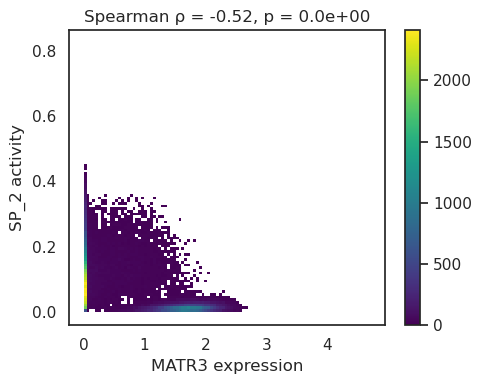

In [97]:
plot_gene_vs_factor_correlation(
    splice_adata=splice_adata,
    ge_adata=ge_adata,
    gene_name="MATR3",
    factor_col="SP_2",
    plot_type="hist"  # try "scatter", "kde", or "hist"
)

In [98]:
ge_adata.layers

Layers with keys: length_norm, log_norm, predicted_log_norm_tms, raw_counts

## Get UMAP on X_PHI

In [99]:
# Run neighbors and UMAP on X_PHI embedding
# sc.pp.neighbors(filtered_splice_adata, use_rep="X_PHI", n_neighbors=8)
# sc.tl.umap(filtered_splice_adata, random_state=0, min_dist=0.3)

In [100]:
#plot_gene_and_factor_umap_from_phi(
#    splice_adata=filtered_splice_adata,
#    ge_adata=filtered_ge_adata,
#    gene_name="ZWINT",
#    factor_name="Factor_2",
#    groupby="broad_cell_type",
#    group_level="Microglia"
#)

## Summary plots for Aging predictions

In [101]:
ge_adata.obsm["X_scVI_linear"].shape, splice_adata.obsm["X_PHI"].shape

((137893, 20), (137893, 20))

In [110]:
# ensure all cells in ge_adata are in splice_adata are the same 
all(ge_adata.obs_names == splice_adata.obs_names)
ge_adata.obs["age_numeric"] = splice_adata.obs["age_numeric"]

In [120]:
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import cross_val_score
import numpy as np
import pandas as pd

# Encode tissue
le = LabelEncoder()
tissue_encoded = le.fit_transform(ge_adata.obs['tissue']).reshape(-1, 1)
y = ge_adata.obs['age_numeric']

# Scale features (critical for fair comparison!)
scaler_ge = StandardScaler()
scaler_splice = StandardScaler()
scaler_tissue = StandardScaler()

ge_scaled = scaler_ge.fit_transform(ge_adata.obsm["X_scVI_linear"])
splice_scaled = scaler_splice.fit_transform(splice_adata.obsm["X_PHI"])
tissue_scaled = scaler_tissue.fit_transform(tissue_encoded)

# Model 1: Splicing + Tissue (scaled)
X1 = np.hstack([splice_scaled, tissue_scaled])
model1 = RidgeCV(alphas=np.logspace(-3, 3, 20), cv=5).fit(X1, y)
r2_splice = cross_val_score(model1, X1, y, cv=5, scoring='r2').mean()

# Model 2: Gene Expression + Tissue (scaled)
X2 = np.hstack([ge_scaled, tissue_scaled])
model2 = RidgeCV(alphas=np.logspace(-3, 3, 20), cv=5).fit(X2, y)
r2_expression = cross_val_score(model2, X2, y, cv=5, scoring='r2').mean()

# Model 3: All features (scaled)
X3 = np.hstack([ge_scaled, splice_scaled, tissue_scaled])
model3 = RidgeCV(alphas=np.logspace(-3, 3, 20), cv=5).fit(X3, y)
r2_combined = cross_val_score(model3, X3, y, cv=5, scoring='r2').mean()

# Extract meaningful coefficients (now comparable!)
n_ge = ge_scaled.shape[1]
n_splice = splice_scaled.shape[1]

splice_coefs = model1.coef_[:n_splice]
ge_coefs = model2.coef_[:n_ge]
ge_coefs_combined = model3.coef_[:n_ge]
splice_coefs_combined = model3.coef_[n_ge:n_ge+n_splice]

print(f"Cross-validated R² scores:")
print(f"Splicing + Tissue: {r2_splice:.3f}")
print(f"Expression + Tissue: {r2_expression:.3f}")
print(f"Combined: {r2_combined:.3f}")
print(f"Optimal alphas: {model1.alpha_:.3f}, {model2.alpha_:.3f}, {model3.alpha_:.3f}")

# Now coefficients are directly comparable!
print(f"\nCoefficient ranges (now meaningful):")
print(f"Splicing: {splice_coefs.min():.3f} to {splice_coefs.max():.3f}")
print(f"Expression: {ge_coefs.min():.3f} to {ge_coefs.max():.3f}")

# Feature importance ranking
splice_importance = pd.DataFrame({
    'factor': range(len(splice_coefs)),
    'coef_magnitude': np.abs(splice_coefs)
}).sort_values('coef_magnitude', ascending=False)

ge_importance = pd.DataFrame({
    'factor': range(len(ge_coefs)),
    'coef_magnitude': np.abs(ge_coefs)
}).sort_values('coef_magnitude', ascending=False)

print(f"\nTop 5 most important factors:")
print("Splicing:", splice_importance.head()['factor'].tolist())
print("Expression:", ge_importance.head()['factor'].tolist())

Cross-validated R² scores:
Splicing + Tissue: 0.245
Expression + Tissue: 0.449
Combined: 0.475
Optimal alphas: 112.884, 0.001, 0.001

Coefficient ranges (now meaningful):
Splicing: -2.429 to 2.909
Expression: -2.887 to 3.429

Top 5 most important factors:
Splicing: [0, 2, 1, 3, 10]
Expression: [0, 15, 14, 1, 11]


In [117]:
ge_adata.obsm["X_scVI_linear"].min(), ge_adata.obsm["X_scVI_linear"].max()

(-5.3121853, 6.162373)

In [118]:
splice_adata.obsm["X_PHI"].min(), splice_adata.obsm["X_PHI"].max()

(2.275701524270054e-08, 0.9830941659117228)

Filtered out 1 cell types with negative CV R² values
Plotting 30 cell types


Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


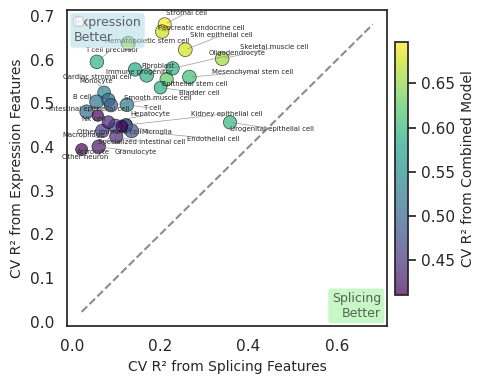

In [103]:
results_df, feature_importance, final_cell_types = figure_plotting.compute_age_r2_with_cv_linear_regression(
     splice_adata, ge_adata, cell_type_col="medium_cell_type", ge_adata_obsm="X_scVI_linear", cv=10, show_top_features=30
 )

filtered_results = figure_plotting.plot_cv_r2_scatter_with_labels(results_df, annotate_top_k=30, show_overfitting=True, save_path=f"{OUTPUT_DIR}/cv_r2_scatter.pdf")

results_df["diff"] = results_df["cv_r2_splicing"] - results_df["cv_r2_expression"]
# sort by absolute difference 
results_df["abs_diff"] = results_df["diff"].abs()
results_df = results_df.sort_values(by="abs_diff", ascending=True)

In [104]:
results_df

,cell_type,n_cells,cv_r2_splicing,cv_r2_expression,cv_r2_combined,cv_std_splicing,cv_std_expression,cv_std_combined,train_r2_splicing,train_r2_expression,train_r2_combined,overfit_splicing,overfit_expression,overfit_combined,n_splice_features,n_expr_features,diff,abs_diff
12,Urogenital epithelial cell,1014,0.358200,0.456595,0.598480,0.117697,0.065861,0.064679,0.427280,0.488455,0.637053,0.069080,0.031860,0.038573,20,20,-0.098395,0.098395
18,Skeletal muscle cell,2469,0.340240,0.602530,0.656501,0.037339,0.025364,0.028350,0.353261,0.610955,0.669213,0.013021,0.008425,0.012712,20,20,-0.262290,0.262290
27,Mesenchymal stem cell,4780,0.266125,0.560558,0.608466,0.042330,0.021670,0.023414,0.274667,0.565453,0.618528,0.008542,0.004895,0.010062,20,20,-0.294433,0.294433
2,Endothelial cell,7103,0.135362,0.437074,0.478152,0.018465,0.018689,0.018534,0.141779,0.441446,0.485957,0.006416,0.004372,0.007805,20,20,-0.301711,0.301711
24,Specialized intestinal cell,1290,0.100466,0.424079,0.439191,0.064621,0.049844,0.043219,0.143803,0.447952,0.486980,0.043337,0.023874,0.047788,20,20,-0.323613,0.323613
15,Microglia,12079,0.121951,0.448774,0.481666,0.031322,0.009929,0.014220,0.135214,0.450889,0.488602,0.013263,0.002115,0.006936,20,20,-0.326822,0.326822
17,Kidney epithelial cell,820,0.122276,0.450356,0.500503,0.099814,0.091055,0.086224,0.184136,0.488204,0.557026,0.061859,0.037848,0.056523,20,20,-0.328080,0.328080
23,Astrocyte,563,0.113226,0.447716,0.410644,0.263659,0.117034,0.150860,0.244078,0.514871,0.545985,0.130852,0.067155,0.135340,20,20,-0.334490,0.334490
30,Bladder cell,526,0.200591,0.536223,0.591535,0.113883,0.057564,0.043036,0.289833,0.589619,0.674713,0.089242,0.053396,0.083178,20,20,-0.335632,0.335632
8,Granulocyte,2864,0.060770,0.400916,0.423696,0.034488,0.051644,0.050440,0.077761,0.412973,0.444639,0.016991,0.012056,0.020943,20,20,-0.340146,0.340146


In [105]:
final_cell_types

['Skin epithelial cell',
 'Other immune cell',
 'Endothelial cell',
 'Smooth muscle cell',
 'Intestinal epithelial cell',
 'Epithelial stem cell',
 'Fibroblast',
 'B cell',
 'Granulocyte',
 'T cell',
 'Immune progenitor',
 'Cardiac stromal cell',
 'Urogenital epithelial cell',
 'Pancreatic endocrine cell',
 'Nk cell',
 'Microglia',
 'T cell precursor',
 'Kidney epithelial cell',
 'Skeletal muscle cell',
 'Hepatocyte',
 'Other epithelial cell',
 'Macrophage',
 'Hematopoietic stem cell',
 'Astrocyte',
 'Specialized intestinal cell',
 'Oligodendrocyte',
 'Monocyte',
 'Mesenchymal stem cell',
 'Stromal cell',
 'Other neuron',
 'Bladder cell']

In [106]:
# Get top 10 factors for BASAL CELL (splicing)
basal_splice = feature_importance["Bladder cell"]["splicing_only"].head(10)
basal_labels = []
basal_coeffs = []

for i in range(10):
    factor_idx = int(basal_splice.iloc[i]["feature_idx"])
    coeff = basal_splice.iloc[i]["coefficient"]
    
    # Get top 3 junctions for this factor
    psi_values = splice_adata.varm["psi_learned"][:, factor_idx]
    top_junction_indices = np.argsort(np.abs(psi_values))[-3:][::-1]
    top_junction_ids = splice_adata.var["gene_name"].iloc[top_junction_indices]
    
    # Extract gene names
    top_genes = [jid.split(':')[0] for jid in top_junction_ids]
    label = '/'.join(top_genes)
    
    basal_labels.append(f"S{factor_idx}: {label}")
    basal_coeffs.append(coeff)

# Get top 10 factors for SKELETAL MUSCLE (expression)
skeletal_ge = feature_importance["Bladder cell"]["expression_only"].head(10)
skeletal_labels = []
skeletal_coeffs = []

for i in range(10):
    factor_idx = int(skeletal_ge.iloc[i]["feature_idx"])
    coeff = skeletal_ge.iloc[i]["coefficient"]
    
    # Get top 3 genes for this factor
    nmf_weights = ge_adata.varm["scVI_linear_gene_loadings"][:, factor_idx]
    top_gene_indices = np.argsort(np.abs(nmf_weights))[-3:][::-1]
    top_gene_names = ge_adata.var["gene_name"].iloc[top_gene_indices]
    
    label = '/'.join(top_gene_names)
    skeletal_labels.append(f"G{factor_idx+1}: {label}")
    skeletal_coeffs.append(coeff)

# Create side-by-side bar plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 7))

# Left: Basal Cell (Splicing)
y_pos1 = np.arange(10)
colors1 = ['purple' if x < 0 else 'green' for x in basal_coeffs]
bars1 = ax1.barh(y_pos1, np.abs(basal_coeffs), color=colors1, alpha=0.7)

ax1.set_yticks(y_pos1)
ax1.set_yticklabels(basal_labels, fontsize=10)
ax1.set_xlabel('|Coefficient|', fontsize=12, weight='bold')
ax1.set_title('T Cell (Splicing)\nCV R² = 0.43', fontsize=10)
ax1.invert_yaxis()

# Add coefficient values
for i, (bar, coef) in enumerate(zip(bars1, basal_coeffs)):
    ax1.text(bar.get_width() + max(np.abs(basal_coeffs)) * 0.02,
             bar.get_y() + bar.get_height()/2, f'{coef:.0f}',
             va='center', fontsize=9, weight='bold')

# Right: Skeletal Muscle (Expression)
y_pos2 = np.arange(10)
colors2 = ['purple' if x < 0 else 'green' for x in skeletal_coeffs]
bars2 = ax2.barh(y_pos2, np.abs(skeletal_coeffs), color=colors2, alpha=0.7)

ax2.set_yticks(y_pos2)
ax2.set_yticklabels(skeletal_labels, fontsize=10)
ax2.set_xlabel('|Coefficient|', fontsize=12, weight='bold')
ax2.set_title('T Cell (Expression)\nCV R² = 0.51', fontsize=10)
ax2.invert_yaxis()

# Add coefficient values
for i, (bar, coef) in enumerate(zip(bars2, skeletal_coeffs)):
    ax2.text(bar.get_width() + max(np.abs(skeletal_coeffs)) * 0.02,
             bar.get_y() + bar.get_height()/2, f'{coef:.0f}',
             va='center', fontsize=9, weight='bold')

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='Green', alpha=0.7, label='Positive (↑ with age)'),
    Patch(facecolor='Purple', alpha=0.7, label='Negative (↓ with age)')
]
fig.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=2)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/panel_e_feature_D_cells_comparison.pdf", dpi=300, bbox_inches='tight')
plt.show()

# Print summary
print("\n CELL (Splicing) - Top 10 factors:")
for label, coeff in zip(basal_labels, basal_coeffs):
    print(f"  {label}: {coeff:.1f}")

print("\n (Expression) - Top 10 factors:")
for label, coeff in zip(skeletal_labels, skeletal_coeffs):
    print(f"  {label}: {coeff:.1f}")

InvalidIndexError: (slice(None, None, None), 11)

In [ ]:
# Example usage (add this to your existing code):
crosstab = plot_simple_age_celltype_heatmap(splice_adata, final_cell_types, save_path=f"{OUTPUT_DIR}/simple_heatmap.pdf")

## Global aging analysis ALL cells using scVI (Z) vs LeafletFA

### Color this plot with cell type category

In [ ]:
# reload figure_plotting
importlib.reload(figure_plotting)

In [ ]:
# Example usage:
results_df, detailed_scores, top_features_df = figure_plotting.global_age_prediction_analysis(
    splice_adata,
    ge_adata, 
    cell_type_col="broad_cell_type",
    ge_adata_obsm="X_scVI_linear"
)

# Top 10 splicing or expression factors:
print(top_features_df[top_features_df["feature"].str.startswith("Splice")].head(10))

# Fix xaxis ticks so normally aligned 
plot_global_results(results_df, detailed_scores, save_path=f"{OUTPUT_DIR}/global_age_prediction.pdf")

In [ ]:
X_PHI = splice_adata.obsm["X_PHI"]

# Boolean mask for non-zero activity
nonzero_mask = X_PHI > 0

# Number of cells with non-zero activity per factor
n_nonzero = nonzero_mask.sum(axis=0)

# Sum of activities where non-zero
sum_nonzero = (X_PHI * nonzero_mask).sum(axis=0)

# Non-zero mean activity (set to 0 if never used)
nonzero_mean_activity = np.divide(sum_nonzero, n_nonzero, out=np.zeros_like(sum_nonzero), where=n_nonzero!=0)

coef_df = top_features_df
coefs = coef_df[coef_df['feature'].str.startswith("Splice")].copy()
coefs["factor_index"] = coefs["feature"].str.extract(r"Splice_(\d+)").astype(int) - 1
coefs["nonzero_mean_activity"] = coefs["factor_index"].map(lambda i: nonzero_mean_activity[i])
coefs["activity_weighted"] = coefs["coefficient"] * coefs["nonzero_mean_activity"]
coefs_sorted = coefs.sort_values("activity_weighted", key=lambda x: x.abs(), ascending=False)
# View top
coefs_sorted

### New circle heatmap combining delta age and activity across cell types

In [49]:
from scipy.cluster.hierarchy import dendrogram, linkage
from matplotlib.patches import Circle
import matplotlib.cm as cm

def plot_factor_circles(adata, cell_type_col='broad_cell_type', age_col='age_group'):
    """
    Create clustered circle heatmap from AnnData object
    
    Parameters:
    -----------
    adata : AnnData object with factors in obsm['X_PHI']
    cell_type_col : column name for cell types
    age_col : column name for age groups (should have 'young' and 'old')
    """
    
    # Extract factor data from PHI matrix
    X_PHI = adata.obsm["X_PHI"]
    n_factors = X_PHI.shape[1]
    factor_cols = [f"SP_{i+1}" for i in range(n_factors)]
    
    # Create DataFrame from PHI matrix
    factor_df = pd.DataFrame(X_PHI, index=adata.obs.index, columns=factor_cols)
        
    # 1. Calculate median expression per cell type (non-zero cells only)
    median_expr = pd.DataFrame(index=adata.obs[cell_type_col].unique(), columns=factor_cols)
    
    for ct in median_expr.index:
        ct_mask = adata.obs[cell_type_col] == ct
        ct_data = factor_df.loc[ct_mask]
        
        # Calculate median of non-zero values for each factor
        for factor in factor_cols:
            factor_values = ct_data[factor]
            non_zero_values = factor_values[factor_values > 0]
            if len(non_zero_values) > 0:
                median_expr.loc[ct, factor] = non_zero_values.median()
            else:
                median_expr.loc[ct, factor] = 0
    
    # Convert to numeric and fill NaN
    median_expr = median_expr.astype(float).fillna(0)
    
    # 2. Calculate delta (old - young) per cell type using non-zero medians
    delta_age = pd.DataFrame(index=median_expr.index, columns=factor_cols)
    
    for ct in median_expr.index:
        ct_mask = adata.obs[cell_type_col] == ct
        
        # Get old and young cells
        old_mask = ct_mask & (adata.obs[age_col] == 'old')
        young_mask = ct_mask & (adata.obs[age_col] == 'young')
        
        if old_mask.sum() > 10 and young_mask.sum() > 10:  # Min cells
            for factor in factor_cols:
                
                # Median of non-zero cells only
                old_values = factor_df.loc[old_mask, factor]
                young_values = factor_df.loc[young_mask, factor]
                delta_age.loc[ct, factor] = old_values.median() - young_values.median()
        else:
            delta_age.loc[ct] = 0
    
    delta_age = delta_age.astype(float).fillna(0)
    
    # 3. Cluster factors by expression patterns
    factor_linkage = linkage(median_expr.T, method='ward')
    factor_order = dendrogram(factor_linkage, no_plot=True)['leaves']
    
    # Cluster cell types
    celltype_linkage = linkage(median_expr, method='ward')
    celltype_order = dendrogram(celltype_linkage, no_plot=True)['leaves']
    celltype_order = [median_expr.index[i] for i in celltype_order]
    
    # Reorder
    median_ordered = median_expr.loc[celltype_order, :].iloc[:, factor_order]
    delta_ordered = delta_age.loc[celltype_order, :].iloc[:, factor_order]
    
    # 4. Create figure without dendrograms
    fig, ax_main = plt.subplots(figsize=(7, 5))
    
    # 5. Plot circles
    n_cells = len(median_ordered)
    n_factors = len(median_ordered.columns)
    
    ax_main.set_xlim(-0.5, n_factors - 0.5)
    ax_main.set_ylim(-0.5, n_cells - 0.5)
    
    # Colormap setup - simple symmetric range
    cmap = plt.cm.BrBG
    vmax = max(abs(delta_ordered.min().min()), abs(delta_ordered.max().max()))
    norm = plt.Normalize(vmin=-vmax, vmax=vmax)
    
    # Plot each circle
    min_size = 0.05  # Minimum visible circle size
    
    for i, cell_type in enumerate(median_ordered.index):
        for j, factor in enumerate(median_ordered.columns):
            expr = median_ordered.iloc[i, j]
            delta = delta_ordered.iloc[i, j]
            
            if expr > 0.001:  # Lower threshold to catch more factors
                # Log transform expression for better visualization
                log_expr = np.log10(expr + 0.01)
                
                # Size with minimum threshold
                size = max(min_size, (log_expr + 2) * 0.15)  # Adjust scaling
                
                # Color by age change
                color = cmap(norm(delta))
                
                circle = Circle((j, i), size, 
                              facecolor=color, 
                              edgecolor='black',
                              linewidth=0.2,
                              alpha=1)
                ax_main.add_patch(circle)
    
    # Labels
    ax_main.set_xticks(range(n_factors))
    ax_main.set_xticklabels(median_ordered.columns, rotation=45, ha='right', fontsize=9)
    ax_main.set_yticks(range(n_cells))
    ax_main.set_yticklabels(median_ordered.index, fontsize=7)

    # Grid
    ax_main.grid(True, alpha=0.3, linestyle=':')
    ax_main.set_axisbelow(True)
    
    # Colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax_main, label='Activity change with age (Old - Young)', shrink=0.8)
    
    plt.tight_layout()
    return fig

In [ ]:
fig = plot_factor_circles(splice_adata)
plt.savefig(f"{OUTPUT_DIR}/delta_median_old_minus_young_by_broad_cell_type_dot_heatmap.pdf", format="pdf", bbox_inches='tight')
print(f"Saved to {OUTPUT_DIR}/delta_median_old_minus_young_by_broad_cell_type_dot_heatmap.pdf")

In [ ]:
ge_adata.obsm["X_scVI_linear"]

In [51]:
# Get data
top_k_genes = 5
fdr_thresh = 0.05
rho_thresh = 0.2 

X_PHI = filtered_splice_adata.obsm["X_PHI"]
X_NMF = filtered_ge_adata.obsm["X_nmf_standard_mb"]
nmf_components = filtered_ge_adata.varm["nmf_standard_mb_components"]  # genes × components
gene_names = filtered_ge_adata.var["gene_name"].values

n_nmf = X_NMF.shape[1]
n_factors = X_PHI.shape[1]

# Build factor dataframe
factor_df = pd.DataFrame(X_PHI, columns=[f"Factor{i+1}" for i in range(n_factors)])
nmf_names = [f"NMF{i+1}" for i in range(n_nmf)]

# Get top-k genes per NMF component
top_genes_dict = {}
for i, comp in enumerate(nmf_names):
    weights = nmf_components[:, i]
    top_idx = np.argsort(-np.abs(weights))[:top_k_genes]
    top_genes = gene_names[top_idx]
    top_genes_dict[comp] = top_genes.tolist()

# Compute correlation and p-value matrices
corr_matrix = np.zeros((n_nmf, n_factors))
pval_matrix = np.zeros((n_nmf, n_factors))

for i in range(n_nmf):
    nmf_activity = X_NMF[:, i]
    for j in range(n_factors):
        rho, pval = spearmanr(nmf_activity, X_PHI[:, j])
        corr_matrix[i, j] = rho
        pval_matrix[i, j] = pval

# FDR correction
_, pvals_fdr_flat, _, _ = multipletests(pval_matrix.flatten(), method='fdr_bh')
fdr_matrix = pvals_fdr_flat.reshape(pval_matrix.shape)

# Annotations for clustermap
annot_matrix = np.where(
        (fdr_matrix < fdr_thresh) & (np.abs(corr_matrix) > rho_thresh),
        "*",
        ""
    )

# Build labels with top genes
nmf_labels = [f"{nmf} ({', '.join(top_genes_dict[nmf])})" for nmf in nmf_names]

# Convert to DataFrame
corr_df = pd.DataFrame(corr_matrix, index=nmf_labels, columns=factor_df.columns)
fdr_df = pd.DataFrame(fdr_matrix, index=nmf_labels, columns=factor_df.columns)

# Save correlation and FDR matrices
corr_df.to_csv(os.path.join(OUTPUT_DIR, "gene_nmf_factor_correlations.csv"))
fdr_df.to_csv(os.path.join(OUTPUT_DIR, "gene_nmf_factor_fdr.csv"))

# Plot clustermap
g = sns.clustermap(
    corr_df,
    cmap="PRGn",
    center=0,
    linewidths=0.2,
    linecolor="black",
    xticklabels=True,
    yticklabels=True,
    annot=annot_matrix,
    fmt='',
    annot_kws={'size': 6, 'color': 'black'},
    figsize=(6,8)
)

# Axes labels
g.ax_heatmap.set_xlabel("Splicing Factors", fontsize=12)
g.ax_heatmap.set_ylabel("Gene NMF Components", fontsize=12)

# Tick labels font size
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=90, ha="right", fontsize=8)
plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=6)  # ← smaller font for NMF labels

# Colorbar (legend) font size
g.cax.tick_params(labelsize=6)  # ← smaller ticks on colorbar
g.cax.set_ylabel(g.cax.get_ylabel(), fontsize=8)  # ← smaller colorbar label

# Save
g.savefig(os.path.join(OUTPUT_DIR, "gene_nmf_factor_correlation_clustermap.pdf"), dpi=300, bbox_inches='tight')
plt.close(g.fig)


In [ ]:
# Build labels with top genes
nmf_labels = [f"{nmf} ({', '.join(top_genes_dict[nmf])})" for nmf in nmf_names]

# Convert to DataFrame
corr_df = pd.DataFrame(corr_matrix, index=nmf_labels, columns=factor_df.columns)
fdr_df = pd.DataFrame(fdr_matrix, index=nmf_labels, columns=factor_df.columns)

# Save correlation and FDR matrices
corr_df.to_csv(os.path.join(OUTPUT_DIR, "gene_nmf_factor_correlations.csv"))
fdr_df.to_csv(os.path.join(OUTPUT_DIR, "gene_nmf_factor_fdr.csv"))

# Plot clustermap with horizontal colorbar
g = sns.clustermap(
    corr_df,
    cmap="PRGn",
    center=0,
    linewidth=0.05,
    linecolor="grey",
    xticklabels=True,
    yticklabels=True,
    annot=annot_matrix,
    fmt='',
    annot_kws={'size': 5, 'color': 'black'},
    figsize=(7,8),
    cbar_pos=(0.5, 0.05, 0.1, 0.1)  # (x, y, width, height) for horizontal colorbar
)

# Axis labels (smaller font)
g.ax_heatmap.set_xlabel("Splicing Factors", fontsize=9)
g.ax_heatmap.set_ylabel("Gene NMF Components", fontsize=9)

# Tick labels (smaller font)
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=90, ha="right", fontsize=6)
plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=6)

# Colorbar label and ticks
g.cax.tick_params(labelsize=4, axis='x')  # ↓ smaller tick labels
g.cax.set_xlabel("Correlation", fontsize=8)

# Save
g.savefig(os.path.join(OUTPUT_DIR, "gene_nmf_factor_correlation_clustermap.pdf"), dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
diff_spl["factor_idx"].value_counts()

In [54]:
def plot_factor_junction_annotation_counts(final_df, output_path):
    """
    Create a stacked barplot showing the number of significant junctions per factor,
    colored by junction annotation category.
    """
    # Count unique junctions by (factor, annotation)
    counts = (
        final_df.groupby(["factor_idx", "junction_annotation"])["junction_id_index"]
        .nunique()
        .reset_index(name="count")
    )
    # Add factor name column
    counts["factor_name"] = "Factor_" + (counts["factor_idx"] +1).astype(str)
    # Pivot to wide format: rows=factor_name, columns=annotation, values=count
    pivot_df = counts.pivot(index="factor_name", columns="junction_annotation", values="count").fillna(0)
    # print table
    print(pivot_df)
    # Sort by total number of junctions
    pivot_df["total"] = pivot_df.sum(axis=1)
    pivot_df = pivot_df.sort_values("total", ascending=False)
    pivot_df = pivot_df.drop(columns="total")
    # Plot
    plt.figure(figsize=(6, 3))
    pivot_df.plot(
        kind="bar",
        stacked=True,
        colormap="viridis",  # Or use sns.color_palette("Set2", n_colors=...)
        edgecolor="black"
    )
    plt.title("Number of Significant Junctions per Factor by Annotation", fontsize=14, fontweight="bold")
    plt.xlabel("Factor", fontsize=12)
    plt.ylabel("Number of Significant Junctions", fontsize=12)
    plt.xticks(rotation=45, ha="right", fontsize=10)
    plt.yticks(fontsize=10)
    plt.legend(title="Junction Annotation", fontsize=9, title_fontsize=10, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    # Save
    plt.savefig(output_path, dpi=300)
    plt.close()

In [ ]:
plot_factor_junction_annotation_counts(diff_spl, os.path.join(OUTPUT_DIR, "differential_splicing_annotation_counts_barplot.pdf"))

In [56]:
def plot_junction_factor_distribution(final_df, output_path):
    """Create an improved histogram showing distribution of factors per junction"""
    # Get counts of factors/junction
    junc_counts = final_df.groupby("junction_id_index")["factor_idx"].nunique()
    junc_counts_df = pd.DataFrame({"junction_id_index": junc_counts.index, "num_factors": junc_counts.values})
    # Create figure with appropriate size
    plt.figure(figsize=(6, 5))
    # Create histogram with better styling
    ax = sns.histplot(junc_counts_df["num_factors"], bins=range(1, junc_counts_df["num_factors"].max() + 2), 
                     kde=True, color='steelblue', edgecolor='darkblue', alpha=0.7)
    # Add mean line
    mean_factors = junc_counts_df["num_factors"].mean()
    plt.axvline(mean_factors, color='red', linestyle='--', linewidth=2)
    plt.text(mean_factors + 0.2, plt.ylim()[1]*0.9, f'Mean: {mean_factors:.2f}', 
             color='red', fontweight='bold')
    # Add title and labels with better formatting
    plt.title("Distribution of Factors per Junction (Significant Only)", fontsize=14, fontweight='bold')
    plt.xlabel("Number of factors affecting junction", fontsize=12)
    plt.ylabel("Count of junctions", fontsize=12)
    # Add grid for better readability
    plt.grid(axis='y', alpha=0.3)
    # Adjust layout
    plt.tight_layout()
    # Save figure with higher DPI
    plt.savefig(output_path, dpi=300)
    plt.close()

In [57]:
plot_junction_factor_distribution(diff_spl, os.path.join(OUTPUT_DIR, "differential_splicing_barplot.pdf"))

In [ ]:
# Reset junction_id_index column 
psi_samples = leaflet_model["psi_samples"]
filtered_splice_adata.var["junction_id_index"] = np.arange(filtered_splice_adata.n_vars)
print("\n>> Running analysis functions...")
results = ds.analyze_all_factors_psi(psi_samples, top_junctions=filtered_splice_adata.var["junction_id_index"].values, min_effect_size=0.2)
all_results = []

for factor_idx, (effect_size_list, significance_df) in results.items():
    # Append to list
    all_results.append(significance_df)
    print("\n>> Running analysis functions...")

# Concatenate all results into a single DataFrame
final_df = pd.concat(all_results, ignore_index=True)
final_df["junction_id_index"] = final_df["junction_idx"]
# convert splice_adata.var["junction_id_index"] to dtype int64
filtered_splice_adata.var["junction_id_index"] = filtered_splice_adata.var["junction_id_index"].astype("int64")

# Merge with adata.var using junction_id_index
final_df = final_df.merge(filtered_splice_adata.var, on="junction_id_index")

In [59]:
# Step 2: Rename and map
final_df = final_df.rename(columns={"factor_idx": "old_factor_idx"})
final_df["factor_idx"] = final_df["old_factor_idx"].map(old_to_new_factor_idx)

In [ ]:
# Create boolean masks for gene types
is_aging_gene = final_df["gene_name"].isin(aging_genes_mouse)
is_rbp_gene = final_df["gene_name"].isin(rbps)

# Initialize junction_label with 'Other'
final_df["junction_label"] = "Other"
final_df.loc[is_rbp_gene, "junction_label"] = "RBP"
final_df.loc[is_aging_gene, "junction_label"] = "Aging"

# Set 'Aging+RBP' if it's both (this will overwrite 'Aging' or 'RBP' if applicable)
final_df.loc[is_aging_gene & is_rbp_gene, "junction_label"] = "Aging+RBP"
final_df = final_df.merge(atse_df, on="junction_id")
print(final_df.junction_label.value_counts())

In [ ]:
final_df["factor_idx"].min()

In [62]:
def plot_individual_factor_junction_analysis(final_df, results_dir, top_n=50):
    """
    Create individual plots for each factor showing their effect on top junctions.
    
    Args:
        final_df: DataFrame with columns ['junction_id_index', 'gene_name', 'junction_label', 'factor_idx', 'effect_size']
        results_dir: Base results directory
        top_n: Number of top junctions to show per factor
    """
    
    # Create DS_FACTORS directory
    ds_factors_dir = os.path.join(results_dir, "DS_FACTORS")
    os.makedirs(ds_factors_dir, exist_ok=True)
    print(f"Creating individual factor plots in: {ds_factors_dir}")
    
    # Junction type color mapping
    label_colors_map = {"Aging": "gold", "RBP": "lightgreen", "Aging+RBP": "orange", "Other": "lightgray"}
    
    # Get unique factors
    unique_factors = sorted(final_df["factor_idx"].unique())
    print(f"Found {len(unique_factors)} factors to analyze")
    
    for factor_idx in unique_factors:
        
        print(f"  Processing Factor_{factor_idx+1}...")
        
        # Filter data for this factor
        factor_df = final_df[final_df["factor_idx"] == factor_idx].copy()
        
        # Get top N junctions by absolute effect size for this factor
        factor_df["abs_effect_size"] = factor_df["effect_size"].abs()
        top_junctions = factor_df.nlargest(top_n, "abs_effect_size")
                
        # Create publication-ready plot with 3 subplots
        # Calculate height based on number of junctions (min 6", max 12")
        fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8, 7), 
                                            gridspec_kw={'width_ratios': [3.5, 1.25, 1.25]})
        
        # Set publication-ready style
        plt.rcParams.update({
            'font.size': 10,
            'axes.titlesize': 12,
            'axes.labelsize': 11,
            'xtick.labelsize': 9,
            'ytick.labelsize': 9,
            'legend.fontsize': 9,
            'figure.titlesize': 14
        })
        
        # ---- Left plot: Horizontal bar chart of effect sizes ----
        
        # Prepare data for plotting
        plot_data = top_junctions.copy()
        plot_data["display_label"] = plot_data.apply(
            lambda row: f"{row['gene_name_x']} (J{row['junction_id_index']})", axis=1
        )
        
        # Sort by effect size for better visualization
        plot_data = plot_data.sort_values("effect_size", ascending=True)
        
        # Create color array based on junction labels
        colors = [label_colors_map.get(label, "lightgray") for label in plot_data["junction_label"]]
        
        # Create horizontal bar plot with publication styling
        bars = ax1.barh(range(len(plot_data)), plot_data["effect_size"], 
                       color=colors, edgecolor='black', linewidth=0.8, alpha=0.85)
        
        # Customize left plot with publication standards
        ax1.set_yticks(range(len(plot_data)))
        ax1.set_yticklabels(plot_data["display_label"], fontsize=8)
        ax1.set_xlabel("Effect Size", fontsize=11, fontweight='bold')
        ax1.set_title(f"Factor {factor_idx+1}: Top {len(plot_data)} Affected Junctions", 
                     fontsize=12, fontweight='bold', pad=15)
        ax1.axvline(x=0, color='black', linestyle='-', linewidth=1.0)
        ax1.grid(axis='x', alpha=0.4, linewidth=0.5)
        ax1.spines['top'].set_visible(False)
        ax1.spines['right'].set_visible(False)
        ax1.spines['left'].set_linewidth(0.8)
        ax1.spines['bottom'].set_linewidth(0.8)
        
        # Add effect size values on bars with better formatting
        for i, (bar, effect) in enumerate(zip(bars, plot_data["effect_size"])):
            width = bar.get_width()
            x_pos = width + (0.02 if width >= 0 else -0.02)
            ha = 'left' if width >= 0 else 'right'
            ax1.text(x_pos, bar.get_y() + bar.get_height()/2, f'{effect:.3f}', 
                    ha=ha, va='center', fontsize=7, fontweight='normal')
        
        # ---- Right plot 1: Junction type distribution ----
        
        # Count junction types
        type_counts = plot_data["junction_label"].value_counts()
        
        # Create publication-ready pie chart
        colors_pie = [label_colors_map.get(label, "lightgray") for label in type_counts.index]
        wedges, texts, autotexts = ax2.pie(type_counts.values, labels=type_counts.index, 
                                          colors=colors_pie, autopct='%1.1f%%', 
                                          startangle=90, textprops={'fontsize': 8},
                                          wedgeprops={'linewidth': 0.8, 'edgecolor': 'white'})
        
        # Style the percentage labels
        for autotext in autotexts:
            autotext.set_color('black')
            autotext.set_fontweight('bold')
            autotext.set_fontsize(8)
        
        ax2.set_title(f"Junction Type\n(n={len(plot_data)})", 
                     fontsize=10, fontweight='bold', pad=10)
        
        # ---- Right plot 2: Junction annotation distribution ----
        
        # Count junction annotations (if the column exists)
        if 'junction_annotation' in plot_data.columns:
            annotation_counts = plot_data["junction_annotation"].value_counts()
            
            # Create publication-ready color palette for annotations
            n_annotations = len(annotation_counts)
            annotation_colors = plt.cm.Set3(np.linspace(0, 1, n_annotations))
            
            # Create pie chart for annotations with publication styling
            wedges3, texts3, autotexts3 = ax3.pie(annotation_counts.values, 
                                                  labels=annotation_counts.index, 
                                                  colors=annotation_colors, 
                                                  autopct='%1.1f%%', 
                                                  startangle=90, 
                                                  textprops={'fontsize': 7},
                                                  wedgeprops={'linewidth': 0.8, 'edgecolor': 'white'})
            
            # Style the percentage labels
            for autotext in autotexts3:
                autotext.set_color('black')
                autotext.set_fontweight('bold')
                autotext.set_fontsize(7)
            
            ax3.set_title(f"Junction Annotation\n(n={len(plot_data)})", 
                         fontsize=10, fontweight='bold', pad=10)
        else:
            # If junction_annotation column doesn't exist, show a clean message
            ax3.text(0.5, 0.5, 'Junction annotation\ndata not available', 
                    ha='center', va='center', fontsize=10,
                    bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgray', 
                             alpha=0.3, edgecolor='gray', linewidth=0.8))
            ax3.set_title("Junction Annotation", fontsize=10, fontweight='bold', pad=10)
            ax3.set_xlim(-1, 1)
            ax3.set_ylim(-1, 1)
            ax3.axis('off')
                
        # ---- Create publication-ready legend ----
        
        # Create legend for junction types
        legend_handles = [plt.Rectangle((0,0),1,1, color=color, label=label, 
                                       edgecolor='black', linewidth=0.5) 
                         for label, color in label_colors_map.items() 
                         if label in plot_data["junction_label"].values]
        
        if legend_handles:  # Only create legend if there are items
            fig.legend(handles=legend_handles, 
                      title="Junction Type", 
                      loc="lower center", 
                      bbox_to_anchor=(0.5, -0.02),
                      ncol=min(4, len(legend_handles)),
                      frameon=True, 
                      fontsize=9, 
                      title_fontsize=10,
                      edgecolor='black',
                      fancybox=True,
                      shadow=True)
        
        # ---- Save publication-ready plot ----
        
        plt.tight_layout(rect=[0, 0.08, 1, 0.97])  # Better spacing for publication
        
        output_path = os.path.join(ds_factors_dir, f"Factor_{factor_idx+1}_junction_analysis.pdf")
        plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
        plt.close()
        
        print(f"    ✓ Saved: factor_{factor_idx+1}_junction_analysis.pdf")
            
        # ---- Make junction-specific clustermap ----
            
        print(f"    Creating junction-specific clustermap for factor_{factor_idx+1}...")
            
        # Get the top junction IDs for this factor
        top_junction_ids = top_junctions["junction_id_index"].unique()
            
        # Filter final_df to get ALL factor effects on these specific junctions
        junction_specific_df = final_df[final_df["junction_id_index"].isin(top_junction_ids)].copy()
            
        if not junction_specific_df.empty and len(junction_specific_df["factor_idx"].unique()) > 1:
            # Create pivot table: rows=junctions, columns=factors, values=effect_size
            clustermap_data = junction_specific_df.pivot_table(
                index=["junction_id_index", "gene_name_x", "junction_label"],
                columns="factor_idx",
                values="effect_size",
                fill_value=0
            )
            
            # Rename columns to include "factor_" prefix
            clustermap_data.columns = [f"Factor_{col+1}" for col in clustermap_data.columns]
            
            # Prepare row colors based on junction_label
            junction_types_for_colors = clustermap_data.index.get_level_values("junction_label")
            row_color_series = junction_types_for_colors.map(label_colors_map).rename("Junction Type")
            row_colors_df = row_color_series.to_frame()
            
            # Prepare display labels for y-axis
            display_row_labels = [f"{gene} (J{jid})" for jid, gene, _ in clustermap_data.index]
            clustermap_data_display = clustermap_data.copy()
            clustermap_data_display.index = display_row_labels
            row_colors_df.index = display_row_labels
            
            g = sns.clustermap(
                clustermap_data_display,
                row_colors=row_colors_df,
                cmap="RdBu_r",
                center=0,
                annot=False,
                linewidths=0.3,
                figsize=(6, 7),
                cbar_kws={'label': 'Effect Size'},
                xticklabels=True,
                yticklabels=True
            )
            
            # Highlight the current factor column
            current_factor_col = f"Factor_{factor_idx+1}"
            if current_factor_col in clustermap_data_display.columns:
                # Find the position of the current factor in the reordered columns
                col_order = g.dendrogram_col.reordered_ind
                reordered_cols = clustermap_data_display.columns[col_order]
                if current_factor_col in reordered_cols:
                    highlight_pos = list(reordered_cols).index(current_factor_col)
                    
                    # Add a thick border around the highlighted column
                    ax_heatmap = g.ax_heatmap
                    ax_heatmap.axvline(x=highlight_pos, color='yellow', linewidth=3, alpha=0.8)
                    ax_heatmap.axvline(x=highlight_pos + 1, color='yellow', linewidth=3, alpha=0.8)
            
            # Customize the plot
            plt.setp(g.ax_heatmap.get_xticklabels(), rotation=45, ha='right', fontsize=9)
            plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=8)
            
            # Add title
            g.fig.suptitle(f'All Factor Effects on Top {len(top_junction_ids)} Junctions from Factor {factor_idx+1}\\n(Yellow highlight = Factor {factor_idx})', 
                          fontsize=12, fontweight='bold', y=0.98)
            
            # Create legend for junction types
            legend_handles = [plt.Rectangle((0,0),1,1, color=color, label=label) 
                             for label, color in label_colors_map.items() 
                             if label in junction_types_for_colors.values]
            
            g.fig.legend(handles=legend_handles, 
                        title="Junction Type", 
                        loc="upper left", 
                        bbox_to_anchor=(0.02, 0.95),
                        frameon=True, 
                        fontsize=9, 
                        title_fontsize=10)
            
            # Save the clustermap
            clustermap_path = os.path.join(ds_factors_dir, f"Factor_{factor_idx+1}_junction_clustermap.pdf")
            g.savefig(clustermap_path, dpi=300, bbox_inches='tight')
            plt.close(g.fig)
            
            print(f"    ✓ Saved junction clustermap: Factor_{factor_idx+1}_junction_clustermap.pdf")
        else:
            print(f"    ⚠️ Insufficient data for clustermap (factor_{factor_idx})")
        
        print(f"    ✓ Completed analysis for Factor_{factor_idx+1}")
        print()
        
    return ds_factors_dir

In [ ]:
final_df["gene_name_x"]

In [ ]:
plot_individual_factor_junction_analysis(final_df, OUTPUT_DIR, top_n=50)

In [ ]:
filtered_splice_adata.var[filtered_splice_adata.var["gene_name"] == "MACF1"]

In [ ]:
mouse_event = "ENSMUSG00000028649.18_atse_9"
# need to fix by adding back columns to atse_df 
visualize_atse_event(mouse_event, atse_df, db_mouse,
                 species="mouse", base_width=7, 
                       trans_height=0.2, 
                  padding=200, show_junc_lines=True)

In [67]:
from sklearn.decomposition import PCA, NMF

def analyze_rbp_correlations(splice_adata, ge_adata, ge_layer_name="log_norm", PLOTS_DIR=None, DATA_DIR=None):
    """
    Analyze correlations between RBP gene expression and splicing factors
    
    Args:
        splice_adata: AnnData object with splicing data and X_PHI in obsm
        ge_adata: AnnData object with gene expression data
        ge_layer_name: Name of the layer in ge_adata to use for RBP expression
        PLOTS_DIR: Optional directory to save plot files.
        DATA_DIR: Optional directory to save data files.
    """
    print("Analyzing RBP correlations with splicing factors using NMF...")
    
    # Add assert statement to check that the two AnnData objects have the exact same cells in the same order
    assert np.all(splice_adata.obs["cell_id"].values == ge_adata.obs["cell_id"].values)
    
    # Ensure RBP_gene column exists in ge_adata.var
    if "RBP_gene" not in ge_adata.var.columns:
        print("  Error: 'RBP_gene' column not found in ge_adata.var")

    # Get RBP mask
    rbp_mask = ge_adata.var["RBP_gene"].values

    # Get RBP expression from input layer in ge_layer_name 
    rbp_expr = ge_adata.layers[ge_layer_name][:, rbp_mask]
    if scipy.sparse.issparse(rbp_expr):
        rbp_expr = rbp_expr.toarray()

    # Check for and clip negative values
    if np.any(rbp_expr < 0):
        print("  Warning: Negative values found in RBP expression data. Clipping to zero for NMF.")
        rbp_expr = np.clip(rbp_expr, 0, None)
    
    # Filter out genes with all-zero expression after potential clipping
    non_zero_genes_mask = np.any(rbp_expr > 0, axis=0) # NMF requires non-negative, so check for > 0
    rbp_expr = rbp_expr[:, non_zero_genes_mask]
    
    # Get the gene names after filtering
    rbp_gene_names = ge_adata.var["gene_name"].values[rbp_mask][non_zero_genes_mask]
    print(rbp_gene_names)
            
    print(f"  Analyzing {len(rbp_gene_names)} RBP genes with non-zero expression using NMF")
    
    # Perform NMF to get latent representation of RBPs
    n_components_nmf = min(10, rbp_expr.shape[1]) # Ensure n_components is not more than features
    nmf = NMF(n_components=n_components_nmf, init='nndsvda', random_state=42, max_iter=200)
    rbp_latent_nmf = nmf.fit_transform(rbp_expr)
    
    # Create a dictionary to store top RBPs per NMF component
    top_rbps_dict_nmf = {}
    
    # Get NMF components (loadings)
    nmf_components = pd.DataFrame(
        nmf.components_.T,
        index=rbp_gene_names,
        columns=[f"NMF{i+1}" for i in range(nmf.n_components_)]
    )
    
    # Get top RBPs per component
    for comp_col in nmf_components.columns:
        top_rbps = nmf_components[comp_col].abs().sort_values(ascending=False).head(10)
        top_rbps_dict_nmf[comp_col] = top_rbps.index.tolist()
    
    # Convert to a DataFrame
    top_rbps_df_nmf = pd.DataFrame.from_dict(top_rbps_dict_nmf, orient='index')
    top_rbps_df_nmf.columns = [f"TopRBP{i+1}" for i in range(top_rbps_df_nmf.shape[1])]
    
    # Save top RBPs
    if DATA_DIR:
        top_rbps_df_nmf.to_csv(os.path.join(DATA_DIR, "top_rbps_per_nmf_component.csv"))
    
    # Wrap factor activity in a DataFrame
    n_factors = splice_adata.obsm["X_PHI"].shape[1]
    factor_df = pd.DataFrame(
        splice_adata.obsm["X_PHI"],
        index=splice_adata.obs_names,
        columns=[f"Factor{i+1}" for i in range(n_factors)]
    )
    
    # Dimensions
    n_nmf = rbp_latent_nmf.shape[1]
    n_factors = factor_df.shape[1]
    nmf_names = [f"NMF{i+1}" for i in range(n_nmf)]
    factor_names = list(factor_df.columns)

    # Initialize correlation and p-value matrices
    corr_matrix = np.zeros((n_nmf, n_factors))
    pval_matrix = np.zeros((n_nmf, n_factors))

    # Calculate correlations
    for i in range(n_nmf):
        print(f"  Calculating correlations for NMF component {nmf_names[i]}...")
        nmf_activity = rbp_latent_nmf[:, i]
        for j in range(n_factors):
            factor_activity = factor_df.iloc[:, j]
            rho, pval = spearmanr(nmf_activity, factor_activity)
            corr_matrix[i, j] = rho
            pval_matrix[i, j] = pval

    # Build DataFrames
    corr_df = pd.DataFrame(corr_matrix, index=nmf_names, columns=factor_names)
    pval_df = pd.DataFrame(pval_matrix, index=nmf_names, columns=factor_names)

    # FDR correction
    pvals_flat = pval_matrix.flatten()
    _, pvals_fdr_flat, _, _ = multipletests(pvals_flat, method='fdr_bh')
    pvals_fdr_matrix = pvals_fdr_flat.reshape(pval_matrix.shape)
    fdr_df = pd.DataFrame(pvals_fdr_matrix, index=nmf_names, columns=factor_names)

    # Significance: FDR < 0.05 and |rho| > 0.1
    sig_matrix = (fdr_df < 0.05) & (np.abs(corr_df) > 0.2)
    annot_matrix = np.where(sig_matrix, '*', '')

    # Save CSVs
    if DATA_DIR:
        corr_df.to_csv(os.path.join(DATA_DIR, "rbp_nmf_factor_correlations.csv"))
        fdr_df.to_csv(os.path.join(DATA_DIR, "rbp_nmf_factor_pvals_fdr.csv"))
        print(f"  Saved NMF-Factor correlation matrices to {DATA_DIR}")

    # Label rows with top 3 RBPs (if available)
    nmf_labels = []
    for nmf_name in nmf_names:
        if nmf_name in top_rbps_dict_nmf:
            top_rbps = top_rbps_dict_nmf[nmf_name][:5]
            nmf_labels.append(f"{nmf_name}({', '.join(top_rbps)})")
        else:
            print(f"Warning: {nmf_name} not in top_rbps_dict_nmf")
            nmf_labels.append(nmf_name)

    # Plot clustermap with significance stars
    if PLOTS_DIR:
        plt.figure(figsize=(7, 4))
        g = sns.clustermap(
            corr_df,
            cmap="PRGn",
            center=0,
            linewidths=0.2,
            linecolor="black",
            xticklabels=True,
            yticklabels=nmf_labels,
            figsize=(6, 4),
            annot=annot_matrix,
            fmt='',
            annot_kws={'size': 6, 'color': 'black'}
        )
        g.ax_heatmap.set_xlabel("Splicing Factors", fontsize=12)
        g.ax_heatmap.set_ylabel("RBP NMF Components", fontsize=12)
        plt.setp(g.ax_heatmap.get_xticklabels(), rotation=90, fontsize=8)
        plt.setp(g.ax_heatmap.get_yticklabels(), fontsize=6)
        plt.tight_layout()
        plt.savefig(os.path.join(PLOTS_DIR, "rbp_nmf_factor_correlations_clustermap.pdf"),
                    format='pdf', bbox_inches='tight')
        plt.close()
    else:
        print("No PLOTS_DIR set. Skipping heatmap.")
    return corr_df, nmf_components, top_rbps_df_nmf, rbp_latent_nmf

In [ ]:
corr_df, nmf_components, top_rbps_df_nmf, rbp_latent_nmf = analyze_rbp_correlations(filtered_splice_adata, filtered_ge_adata, ge_layer_name="log_norm", PLOTS_DIR=OUTPUT_DIR)

In [69]:
def correlate_single_rbp_with_factors(splice_adata, ge_adata, rbp_gene_list, ge_layer_name="predicted_log_norm_tms", PLOTS_DIR=None, DATA_DIR=None, top_rbps_df_nmf=None):
    """
    Calculate Spearman correlation between individual RBP gene expression and splicing factor activities.
    If top_rbps_df_nmf is provided, will use those RBPs instead of the full rbp_gene_list.
    Performs FDR correction on p-values and adds significance stars to the clustermap.

    Args:
        splice_adata: AnnData with X_PHI in obsm.
        ge_adata: AnnData with gene expression, must have ge_layer_name and var['gene_name'].
                  Cells must be aligned with splice_adata.
        rbp_gene_list: A list of RBP gene names (must match ge_adata.var['gene_name']).
        ge_layer_name: Layer in ge_adata to use for RBP expression.
        PLOTS_DIR: Directory to save plots.
        DATA_DIR: Directory to save data files.
        top_rbps_df_nmf: Optional DataFrame containing top RBPs from NMF analysis.

    Returns:
        pandas.DataFrame with RBP genes as rows, Factors as columns, and correlation rho as values.
        pandas.DataFrame with RBP genes as rows, Factors as columns, and FDR-adjusted p-values as values.
    """
    print("Correlating single RBP gene expression with splicing factors...")
    
    # Assert cells are aligned in both adata objects using "cell_id" column in .obs 
    assert np.all(splice_adata.obs["cell_id"].values == ge_adata.obs["cell_id"].values), "Cells in splice_adata and ge_adata are not aligned."

    X_phi = splice_adata.obsm["X_PHI"]
    n_factors = X_phi.shape[1]
    factor_names = [f"Factor{i+1}" for i in range(n_factors)]

    # If top_rbps_df_nmf is provided, use those RBPs instead
    if top_rbps_df_nmf is not None:
        print("  Using top RBPs from NMF analysis...")
        # Extract unique RBP genes from all columns of top_rbps_df_nmf
        unique_rbps = set()
        for col in top_rbps_df_nmf.columns:
            unique_rbps.update(top_rbps_df_nmf[col].dropna().tolist())
        rbp_gene_list = list(unique_rbps)
        print(f"  Found {len(rbp_gene_list)} unique RBPs from NMF analysis")

    valid_rbps = []
    rbp_indices_in_ge = []
    for rbp in rbp_gene_list:
        if rbp in ge_adata.var["gene_name"].values:
            valid_rbps.append(rbp)
            rbp_indices_in_ge.append(ge_adata.var_names[ge_adata.var["gene_name"] == rbp][0])
        else:
            print(f"  Warning: RBP '{rbp}' not found in ge_adata.var['gene_name']. Skipping.")
    
    rbp_expr_matrix = ge_adata[:, rbp_indices_in_ge].layers[ge_layer_name]
    if scipy.sparse.issparse(rbp_expr_matrix):
        rbp_expr_matrix = rbp_expr_matrix.toarray()

    print("  Calculating correlations using vectorized operations...")
    
    # Calculate correlations for all factors and RBPs at once using numpy's vectorized operations
    n_rbps = rbp_expr_matrix.shape[1]
    corr_matrix = np.zeros((n_rbps, n_factors))
    pval_matrix = np.zeros((n_rbps, n_factors))
    
    # For each factor, calculate correlations with all RBPs at once
    for j in range(n_factors):
        print(f"  Calculating correlations for factor {factor_names[j]}...")
        factor_activity = X_phi[:, j]
        # Calculate correlations for all RBPs with this factor
        for i in range(n_rbps):
            rho, pval = spearmanr(factor_activity, rbp_expr_matrix[:, i])
            corr_matrix[i, j] = rho
            pval_matrix[i, j] = pval
    
    # Create DataFrames
    corr_df = pd.DataFrame(corr_matrix, index=valid_rbps, columns=factor_names)

    # Perform FDR correction on p-values
    pvals_flat = pval_matrix.flatten()
    _, pvals_fdr, _, _ = multipletests(pvals_flat, method='fdr_bh')
    pvals_fdr_matrix = pvals_fdr.reshape(pval_matrix.shape)
    fdr_df = pd.DataFrame(pvals_fdr_matrix, index=valid_rbps, columns=factor_names)

    # Create significance matrix (True where both FDR < 0.05 and |cor| > 0.1)
    sig_matrix = (fdr_df < 0.05) & (np.abs(corr_df) > 0.2)

    # Save DataFrames to CSV
    if DATA_DIR:
        corr_df.to_csv(os.path.join(DATA_DIR, "single_rbp_factor_correlations_rho.csv"))
        fdr_df.to_csv(os.path.join(DATA_DIR, "single_rbp_factor_correlations_fdr.csv"))
        print(f"  Saved RBP-Factor correlation matrices to {DATA_DIR}")

    # Plot heatmap with significance stars
    if PLOTS_DIR:
        plt.figure(figsize=(5,6))
        
        # Create annotation matrix with stars for significant correlations
        annot_matrix = np.where(sig_matrix, '*', '')
        
        # Create clustermap
        g = sns.clustermap(
            corr_df, 
            cmap="PRGn", 
            center=0, 
            linewidths=0.2,
            xticklabels=True, 
            yticklabels=True, 
            linecolor='black', 
            figsize=(5,6),
            annot=annot_matrix,
            fmt='',
            annot_kws={'size': 6, 'color': 'black'}
        )

        # Adjust clustermap tick sizes 
        plt.setp(g.ax_heatmap.get_xticklabels(), fontsize=8)
        plt.setp(g.ax_heatmap.get_yticklabels(), fontsize=6)

        plt.tight_layout()
        
        # Add legend for significance
        plt.figtext(0.01, 0.01, '* FDR < 0.05 and |cor| > 0.2', fontsize=5)
        
        plt.savefig(os.path.join(PLOTS_DIR, "single_rbp_factor_correlations_heatmap.pdf"), format='pdf', bbox_inches='tight')
        plt.close()
        print(f"  Saved RBP-Factor correlation heatmap to {PLOTS_DIR}")
    
    return corr_df, fdr_df

In [ ]:
top_rbps_df_nmf

In [ ]:
# Look at individual RBP-Factor correlations
print("   :gear: Correlating single RBP gene expression with splicing factors...")
list_of_rbps_for_corr = filtered_ge_adata.var.gene_name[ge_adata.var["RBP_gene"]].tolist()
print(f"   :gear: Correlating single RBP gene expression with splicing factors for {len(list_of_rbps_for_corr)} RBPs")
correlate_single_rbp_with_factors(
        filtered_splice_adata, filtered_ge_adata, rbp_gene_list=list_of_rbps_for_corr, 
        ge_layer_name="log_norm", PLOTS_DIR=OUTPUT_DIR, DATA_DIR=DATA_DIR, top_rbps_df_nmf=top_rbps_df_nmf)

In [ ]:
import matplotlib.pyplot as plt

# Compute enrichment dataframe (as you already have)
junction_counts = diff_spl["junction_idx"].value_counts()
singleton_junctions = junction_counts[junction_counts == 1].index
singleton_df = diff_spl[diff_spl["junction_idx"].isin(singleton_junctions)].copy()
singleton_counts_by_factor = singleton_df["factor_idx"].value_counts().sort_index()
all_counts_by_factor = diff_spl["factor_idx"].value_counts().sort_index()

enrichment_df = pd.DataFrame({
    "singleton_count": singleton_counts_by_factor,
    "all_count": all_counts_by_factor
}).fillna(0)

enrichment_df["fraction_singletons"] = enrichment_df["singleton_count"] / enrichment_df["singleton_count"].sum()
enrichment_df["fraction_all"] = enrichment_df["all_count"] / enrichment_df["all_count"].sum()
enrichment_df["enrichment"] = enrichment_df["fraction_singletons"] / enrichment_df["fraction_all"]

# Generate x-axis labels as Factor 1, Factor 2, ...
factor_labels = [f"Factor {i+1}" for i in enrichment_df.index]

# Plot
plt.figure(figsize=(8, 4))  # narrower width
plt.bar(factor_labels, enrichment_df["enrichment"])
plt.axhline(1.0, linestyle="--", color="black")
plt.xlabel("Factor")
plt.ylabel("Singleton Enrichment Ratio")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [ ]:
# plot expression of MATR3 vs Factor 2 activity in top 10 cell types using separate curves for each cell types
filtered_splice_adata, filtered_ge_adata

In [ ]:
plot_factor_violin_sorted(
    adata=filtered_splice_adata,
    factor_list=["Factor_2"],
    groupby="broad_cell_type",
    top_n=10,
    cmap="YlGnBu",
    save_prefix="sorted_violin",
    width=4,
    height=5
)


In [ ]:
# Step 1: Extract MATR3 expression from the correct layer
gene = "MATR3"
if gene not in filtered_ge_adata.var["gene_name"].values:
    raise ValueError(f"{gene} not found in gene expression AnnData")

gene_idx = filtered_ge_adata.var.query("gene_name == @gene").index[0]
matr3_expr = filtered_ge_adata.layers["log_norm"][:, filtered_ge_adata.var_names.get_loc(gene_idx)].toarray().flatten()

# Step 2: Build a DataFrame with expression, factor activity, and cell type
df = pd.DataFrame({
    "MATR3_expression": matr3_expr,
    "Factor_2": filtered_splice_adata.obs.loc[:, "Factor_2"].values,
    "broad_cell_type": filtered_ge_adata.obs.loc[:, "broad_cell_type"].values
})

# Step 3: Select top 10 most common cell types
top_celltypes = ["B Cell", "T Cell"]
df_top = df[df["broad_cell_type"].isin(top_celltypes)]

# --- Step 1–3 already done ---

# Step 4: Scatter + smoothed trend line (per cell type)
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_top,
    x="Factor_2",
    y="MATR3_expression",
    hue="broad_cell_type",
    alpha=0.4,
    s=7,
    linewidth=0
)

plt.title("MATR3 Expression vs. Factor 2 Activity (Top 10 Cell Types)")
plt.xlabel("Factor 2")
plt.ylabel("MATR3 predicted expression (log)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()